In [ ]:
import numpy as np
import pandas as pd
from gurobipy import *

import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import matplotlib.patches as mpatches

## Background and Data Exploration

Forever 67, a hypothetical fast-fashion retailer, seeks to optimize its supply chain. 

The supply chain network is organized in several layers, as shown below.

![](network_graph.JPG)

- Layer A consists of the manufacturing centers, which hold a certain number of container units of apparel in inventory.
- Layer B consists of warehouses, which also hold some number of container units in inventory. 
- Layer C consists of the distribution centers. 
- Layer D consists of the retail centers, each of which is associated with some amount of demand in container units.

*The aim will be to transport units of apparel from the manufacturing centers (Layer A) to retail centers (Layer D) at the lowest cost possible.*

For this notebook, we define a "container unit" as a shipping container rather than an individual item. Ideally, a sophisticated model would account for specific articles and size distributions per store; however, due to the lack of data, we assume a standardized assortment across all locations. Nevertheless, the optimization logic presented here is robust and can be easily scaled to accommodate more granular data.

Node-related Data: 
| Column | Description |
| :--- | :--- |
| **NodeID** | Number to indicate the node; unique to each node. |
| **Layer** | String with single character representing layer of supply chain network that node is in; one of A, B, C, D. |
| **NodeName** | String with name of node (e.g., A4, which indicates fourth node in layer A). (First character will match `Layer`.) |
| **Inventory** | Number of container units already available at node. |
| **Demand** | Number of container units estimated to be demanded at this node. (Forecasted) |
| **BackorderCost** | Fixed unit cost for each container unit that final supply is short of demand. (Only non-zero for nodes in layer D.) |

Note that Demand and BackorderCost are only non-zero for the nodes in the final layer, which correspond to retail locations. 

Note also that Inventory is only non-zero for the nodes in layers A, B, and C.

In [37]:
node_df = pd.read_csv("MCNF_nodes_updated.csv")
node_df.tail()

,NodeID,Layer,NodeName,Inventory,Demand,BackorderCost
35,36,D,D16,0,30,50
36,37,D,D17,0,15,100
37,38,D,D18,0,15,50
38,39,D,D19,0,25,100
39,40,D,D20,0,15,50


Edge-related Data:

| Column | Description |
| :--- | :--- |
| **SourceNodeName** | Name of node (cf. `NodeName` in `MCNF_nodes.csv`) from which the edge originates. |
| **DestinationNodeName** | Name of node (cf. `NodeName` in `MCNF_nodes.csv`) at which the edge ends. |
| **Capacity** | Maximum number of container units that can be transported over this edge. |
| **TransportationCost** | Cost incurred for each container unit transported over this edge. |
| **SourceNodeID** | ID (cf. `NodeID` in `MCNF_nodes.csv`) corresponding to `SourceNodeName`. |
| **DestinationNodeID** | ID (cf. `NodeID` in `MCNF_nodes.csv`) corresponding to `DestinationNodeName`. |

Note that each edge in this network is directed. 

For example, row 3 of `MCNF_edges.csv` is the edge that goes from A1 to B5, which has a capacity of 54 units and a transportation cost of 5. This means that at most 54 container units can be transported from A1 to B5, and each container unit costs 5 to transport.

Note that container units cannot be transported backwards, i.e., we cannot transport container units from B5 to A1.

Lastly, all costs are measured in cost units, i.e., a TransportationCost of 5 means each container
unit results in 5 cost units.

In [38]:
edge_df = pd.read_csv("MCNF_edges.csv")
edge_df.head()

,SourceNodeName,DestinationNodeName,Capacity,UnitCost,SourceNodeID,DestinationNodeID
0,A1,B1,42,20,1,11
1,A1,B2,42,20,1,12
2,A1,B5,54,5,1,15
3,A2,B1,50,15,2,11
4,A2,B2,60,5,2,12


In [39]:
print("Number of nodes: ", node_df.shape[0])
print("Number of edges: ", edge_df.shape[0])

print("\nTotal inventory by layer:")
print(node_df.groupby("Layer")["Inventory"].sum())

print("\nTotal inventory over all layers: ", node_df["Inventory"].sum())
print("Total demand over all layers: ", node_df["Demand"].sum())

Number of nodes:  40
Number of edges:  103

Total inventory by layer:
Layer
A    320
B     80
C     50
D      0
Name: Inventory, dtype: int64

Total inventory over all layers:  450
Total demand over all layers:  395


Notice that total inventory is more than total demand, which means that this is an unbalanced problem, something we need to keep in mind when formulating the problem as a linear program.

## Finding the Optimal Solution

### Formulation 1: Fully Fulfill Demand
Let's determine how many container units Forever 67 should transport along each edge through this supply chain network. 

It needs to so as to 
1. not exceed the capacity of each edge.
2. *FULLY* meet the demand in the nodes in layer D. 

The goal of the firm is to minimize its total transportation cost.

We define our parameters first. Let: 
- $\mathcal{N}$ be the set of nodes in the supply chain network;
- $s_i$ be the available inventory/supply at node $i$;
- $d_i$ be the demand at node $i$;
- $u_{i,j}$ be the capacity of the edge from node $i$ to node $j$ (i.e., the upper bound on the flow from $i$ to $j$);
- $c_{i,j}$ be the transportation cost of the edge from node $i$ to node $j$;
- $\mathcal{E}$ be the set of edges in our network, i.e., pairs $(i,j) \in [n] \times [n]$ such that there exists an edge from node $i$ to $j$. 

Our decision variable is $x_{i,j}$, which is the flow along the edge from node $i$ to node $j$. 

The problem can be then be written as follows:

$$\begin{alignat}{2}
& \text{minimize} & \quad & \sum_{(i,j) \in \mathcal{E}} c_{i,j} x_{i,j} \\
& \text{subject to} & & \sum_{j \in \mathcal{N}: (j,i) \in \mathcal{E}} x_{j,i} + s_i \geq \sum_{j \in \mathcal{N}: (i,j) \in \mathcal{E}} x_{i,j} + d_i, \quad \forall \ i \in \mathcal{N}, \\
& & & x_{i,j} \leq u_{i,j}, \quad \forall\ (i,j) \in \mathcal{E}, \\
& & & x_{i,j} \geq 0, \quad \forall\ (i,j) \in \mathcal{E}.
\end{alignat}$$

Note that the outflow is set to be bigger or equal to the inflow, due to the unbalanced nature of the problem.

In [40]:
nodes = node_df["NodeName"].tolist()
od_pairs = list(zip(edge_df["SourceNodeName"], edge_df["DestinationNodeName"]))

capacity_dict = dict(zip(od_pairs, edge_df["Capacity"]))
cost_dict = dict(zip(od_pairs, edge_df["UnitCost"]))
inventory_dict = dict(zip(nodes, node_df["Inventory"]))
demand_dict = dict(zip(nodes, node_df["Demand"]))

m = Model()
x = m.addVars( od_pairs, lb = 0, ub = capacity_dict)

for n in nodes:
    m.addConstr(sum(x[t] for t in od_pairs if t[0] == n) + demand_dict[n] <= sum(x[t] for t in od_pairs if t[1] == n) + inventory_dict[n])
    
m.setObjective(sum(cost_dict[t] * x[t] for t in od_pairs), GRB.MINIMIZE)

m.update()
m.optimize()

Gurobi Optimizer version 12.0.0 build v12.0.0rc1 (win64 - Windows 10.0 (19045.2))

CPU model: Intel(R) Core(TM) i5-6600K CPU @ 3.50GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 4 logical processors, using up to 4 threads

Optimize a model with 40 rows, 103 columns and 206 nonzeros
Model fingerprint: 0x6d55453d
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [5e+00, 4e+01]
  Bounds range     [3e+01, 8e+01]
  RHS range        [5e+00, 6e+01]
Presolve removed 4 rows and 3 columns
Presolve time: 0.01s
Presolved: 36 rows, 100 columns, 199 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    1.2500000e+03   4.625000e+01   0.000000e+00      0s
      49    1.2265000e+04   0.000000e+00   0.000000e+00      0s

Solved in 49 iterations and 0.01 seconds (0.00 work units)
Optimal objective  1.226500000e+04


In [41]:
print("Optimal cost:", m.ObjVal)
# Solvers use floating-point arithmetic, so values that should be zero can appear as tiny numbers like 1e-12.
print("Number of edges used:", sum(x[e].X > 1e-6 for e in od_pairs))

Optimal cost: 12265.0
Number of edges used: 39


Let's see a visualization of the optimized network flow.

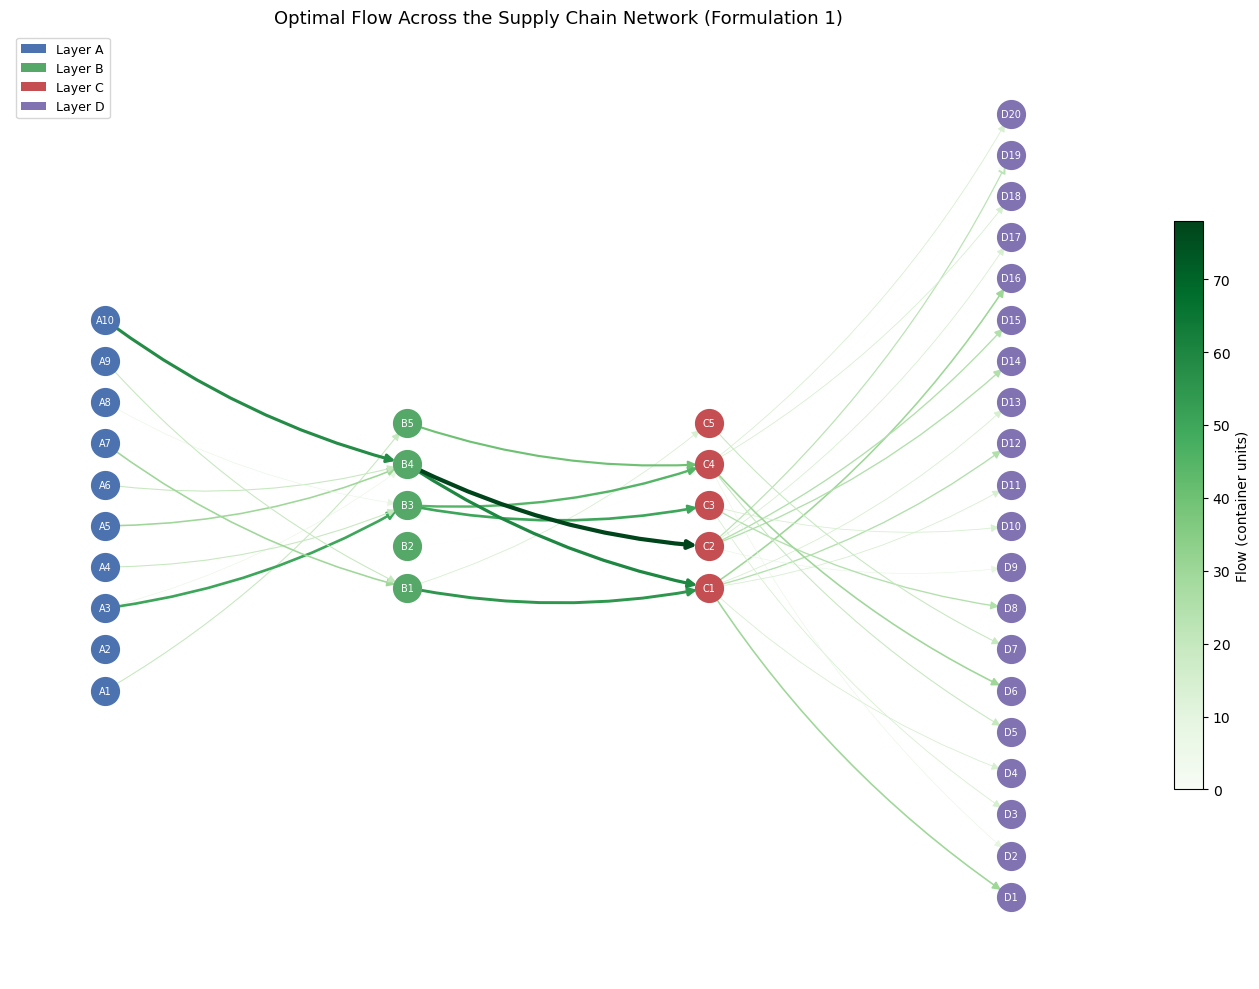

In [42]:
# Build graph from edges with non-zero flow
flow_values = {e: x[e].X for e in od_pairs if x[e].X > 1e-6}
G_viz = nx.DiGraph(flow_values.keys())
G_viz.add_nodes_from(nodes)

# Position nodes: x = layer index, y = rank within layer
layer_order = ['A', 'B', 'C', 'D']
layer_nodes = {l: sorted([n for n in nodes if n[0] == l], key=lambda n: int(n[1:])) for l in layer_order}
pos = {n: (layer_order.index(n[0]), layer_nodes[n[0]].index(n) - len(layer_nodes[n[0]]) / 2) for n in nodes}

# Edge styling scaled to flow
max_flow = max(flow_values.values(), default=1)
norm = mcolors.Normalize(vmin=0, vmax=max_flow)
edge_widths = [3 * flow_values[e] / max_flow for e in flow_values]
edge_colors = [cm.Greens(norm(flow_values[e])) for e in flow_values]

fig, ax = plt.subplots(figsize=(14, 10))

# Draw nodes and labels
layer_colors = {'A': '#4C72B0', 'B': '#55A868', 'C': '#C44E52', 'D': '#8172B2'}
for layer, color in layer_colors.items():
    nx.draw_networkx_nodes(G_viz, pos, nodelist=layer_nodes[layer], node_color=color, node_size=400, ax=ax)
nx.draw_networkx_labels(G_viz, pos, font_size=7, font_color='white', ax=ax)

# Draw edges
nx.draw_networkx_edges(G_viz, pos, edgelist=list(flow_values), width=edge_widths,
                       edge_color=edge_colors, arrows=True, arrowsize=12,
                       connectionstyle='arc3,rad=0.1', ax=ax)

# Legend and colorbar
ax.legend(handles=[Patch(facecolor=c, label=f'Layer {l}') for l, c in layer_colors.items()],
          loc='upper left', fontsize=9)
plt.colorbar(cm.ScalarMappable(cmap=cm.Greens, norm=norm), ax=ax,
             label='Flow (container units)', shrink=0.6)

ax.set_title('Optimal Flow Across the Supply Chain Network (Formulation 1)', fontsize=13)
ax.axis('off')
plt.tight_layout()
plt.show()

### Formulation 2: Fulfill a Set Service Level
Now, the solution above forces every estimated demand at the retail centers to be satisfied, which can be costly. Suggested in *Aardal et al* (see footnote [1] below), an approach is to set a service level constraint for the Minimum Cost Network Flow (MCNF) problem, and to use the shadow price of the service level constraint to approximate the shortage cost.

Let $\mathcal{N}_D$ be the set of nodes in layer $D$, and let us introduce a continuous decision variable $G_i$ for each node $i$ in $\mathcal{N}_D$, which will model the shortfall in that node.

Our modified formulation then has the following form: 

$$\begin{alignat}{2}
& \text{minimize} & \quad & \sum_{(i,j) \in \mathcal{E}} c_{i,j} x_{i,j} \\
& \text{subject to} & & \sum_{j \in \mathcal{N}: (j,i) \in \mathcal{E}} x_{j,i} + s_i + G_i \geq \sum_{j \in \mathcal{N}: (i,j) \in \mathcal{E}} x_{i,j} + d_i, \quad \forall \ i \in \mathcal{N}_D, \\
& & & \sum_{j \in \mathcal{N}: (j,i) \in \mathcal{E}} x_{j,i} + s_i \geq \sum_{j \in \mathcal{N}: (i,j) \in \mathcal{E}} x_{i,j} + d_i, \quad \forall \ i \in \mathcal{N} \setminus \mathcal{N}_D, \\
& & & x_{i,j} \leq u_{i,j}, \quad \forall\ (i,j) \in \mathcal{E}, \\
& & & x_{i,j} \geq 0, \quad \forall\ (i,j) \in \mathcal{E}, \\
& & & G_i \geq 0, \quad \forall \ i \in \mathcal{N}_D, \\
& & & \sum_{i \in \mathcal{N}_D} G_{i} \leq 0.05 \sum_{i \in \mathcal{N}_D} d_i. 
\end{alignat}$$

Note that we now have two version of the flow constraints. The second one, which is enforced for nodes not in layer D, is the same form as in the model from Formulation 1. The first one is only enforced for nodes in layer D, and this constraint now includes $G_i$ on the left hand side. In words, we need to make sure that the inflows to node $i$, the available inventory at $i$ and the shortfall $G_i$ are at least as big as the outflows plus the demand at $i$.

The last constraint is the service level constraint, where we limit the shortfall to be at most, in this case, 5% of the total demand. This is equivalent to a minimum service level of 95% or above.

[1]: K. Aardal, Ö. Jonsson, and H. Jönsson, Optimal inventory policies with service-level constraints, J.Oper.Res.Soc.40 (1989), pp. 65–73.

In [ ]:
# Extract demand nodes:
demand_nodes = [n for n in nodes if n[0] == "D"]

# Formulate model for Formulation 2:
m = Model()

x = m.addVars(od_pairs, lb=0, ub=capacity_dict)

G = m.addVars(demand_nodes, lb=0)

for n in nodes:
    if n in demand_nodes:
        m.addConstr(
            sum(x[t] for t in od_pairs if t[0] == n) + demand_dict[n]
            <= sum(x[t] for t in od_pairs if t[1] == n) + inventory_dict[n] + G[n]
        )
    else:
        m.addConstr(
            sum(x[t] for t in od_pairs if t[0] == n) + demand_dict[n]
            <= sum(x[t] for t in od_pairs if t[1] == n) + inventory_dict[n]
        )

# Service level constraint: total shortfall <= 5% of total demand
service_level_constr = m.addConstr(sum(G[n] for n in demand_nodes) <= 0.05 * sum(demand_dict[n] for n in demand_nodes))

m.setObjective(
    sum(cost_dict[t] * x[t] for t in od_pairs),
    GRB.MINIMIZE,
)

m.update()
m.optimize()

Gurobi Optimizer version 12.0.0 build v12.0.0rc1 (win64 - Windows 10.0 (19045.2))

CPU model: Intel(R) Core(TM) i5-6600K CPU @ 3.50GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 4 logical processors, using up to 4 threads

Optimize a model with 41 rows, 123 columns and 246 nonzeros
Model fingerprint: 0xb9fe27e9
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [5e+00, 4e+01]
  Bounds range     [3e+01, 8e+01]
  RHS range        [5e+00, 6e+01]
Presolve removed 1 rows and 0 columns
Presolve time: 0.00s
Presolved: 40 rows, 123 columns, 245 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    0.0000000e+00   4.690625e+01   0.000000e+00      0s
      52    1.1267500e+04   0.000000e+00   0.000000e+00      0s

Solved in 52 iterations and 0.01 seconds (0.00 work units)
Optimal objective  1.126750000e+04


In [44]:
print("Optimal total cost (Formulation 2): ", m.objval)

G_val = {n: G[n].x for n in demand_nodes}
print("Shortfall in optimal solution: ", G_val)

total_shortfall = sum(G[n].x for n in demand_nodes)
print("Total shortfall: ", total_shortfall)
print("5% of total demand: ", 0.05 * sum(demand_dict[n] for n in demand_nodes))

print("Shadow price of service level constraint: ", service_level_constr.Pi)

Optimal total cost (Formulation 2):  11267.5
Shortfall in optimal solution:  {'D1': 0.0, 'D2': 0.0, 'D3': 0.0, 'D4': 0.0, 'D5': 0.0, 'D6': 2.75, 'D7': 0.0, 'D8': 0.0, 'D9': 0.0, 'D10': 0.0, 'D11': 0.0, 'D12': 0.0, 'D13': 0.0, 'D14': 0.0, 'D15': 17.0, 'D16': 0.0, 'D17': 0.0, 'D18': 0.0, 'D19': 0.0, 'D20': 0.0}
Total shortfall:  19.75
5% of total demand:  19.75
Shadow price of service level constraint:  -50.0


As expected, the optimal solution would produce a shortfall as much as the service level constraint allows. We can also observe that the optimal total cost is already lower than that of the formulation 1.

To visualize how the shadow price changes across different levels of service level constraint, we can create a loop below.

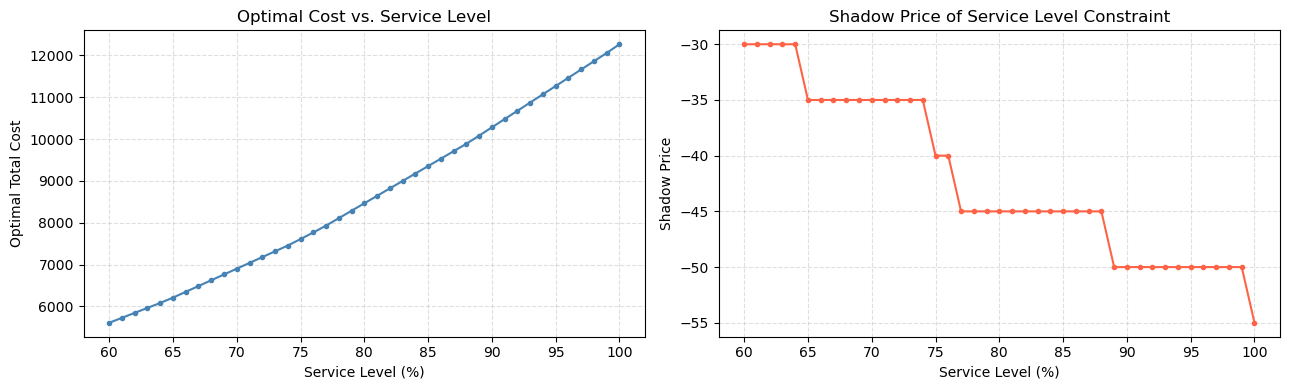

In [45]:
service_levels = [sl / 100 for sl in range(60, 101)]  # 60% to 100%
total_demand = sum(demand_dict[n] for n in demand_nodes)

opt_costs = []
shadow_prices = []

for sl in service_levels:
    m_sl = Model()
    m_sl.params.OutputFlag = 0

    x_sl = m_sl.addVars(od_pairs, lb=0, ub=capacity_dict)
    G_sl = m_sl.addVars(demand_nodes, lb=0)

    for n in nodes:
        if n in demand_nodes:
            m_sl.addConstr(
                sum(x_sl[t] for t in od_pairs if t[0] == n) + demand_dict[n]
                <= sum(x_sl[t] for t in od_pairs if t[1] == n) + inventory_dict[n] + G_sl[n]
            )
        else:
            m_sl.addConstr(
                sum(x_sl[t] for t in od_pairs if t[0] == n) + demand_dict[n]
                <= sum(x_sl[t] for t in od_pairs if t[1] == n) + inventory_dict[n]
            )

    sl_constr = m_sl.addConstr(sum(G_sl[n] for n in demand_nodes) <= (1 - sl) * total_demand)

    m_sl.setObjective(sum(cost_dict[t] * x_sl[t] for t in od_pairs), GRB.MINIMIZE)
    m_sl.optimize()

    opt_costs.append(m_sl.objval)
    shadow_prices.append(sl_constr.Pi)

sl_pct = [sl * 100 for sl in service_levels]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(sl_pct, opt_costs, color='steelblue', linewidth=1.5, marker='o', markersize=3)
ax1.set_xlabel("Service Level (%)")
ax1.set_ylabel("Optimal Total Cost")
ax1.set_title("Optimal Cost vs. Service Level")
ax1.set_xticks(range(60, 101, 5))
ax1.grid(True, linestyle='--', alpha=0.4)

ax2.plot(sl_pct, shadow_prices, color='tomato', linewidth=1.5, marker='o', markersize=3)
ax2.set_xlabel("Service Level (%)")
ax2.set_ylabel("Shadow Price")
ax2.set_title("Shadow Price of Service Level Constraint")
ax2.set_xticks(range(60, 101, 5))
ax2.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

As shown above, the shadow price is a piecewise linear function where it decreases as we tightens the service level, with each piece corresponds to one optimal basis (one fixed set of active edges/constraints). This is consistent with the optimization being a convex problem, where each segment with its own (less negative) shadow price as the service level gets looser. If we have an estimate of the shortage cost through other means, then setting the shadow price (the marginal transportation cost) to be equal to the actual estimated shortage cost would yield us the optimal solution. We can validate this claim in the following analysis.

### Formulation 3: Incorporating Backordering Cost

Let's calculate the optimal solution given the amount of back-ordering cost, rather than setting a set level of service level constraint, and see how the two compares.

Our modified formulation then has the following form: 

$$\begin{alignat}{2}
& \text{minimize} & \quad & \sum_{(i,j) \in \mathcal{E}} c_{i,j} x_{i,j} + \sum_{i \in \mathcal{N}_D} b_i G_i \\
& \text{subject to} & & \sum_{j \in \mathcal{N}: (j,i) \in \mathcal{E}} x_{j,i} + s_i + G_i \geq \sum_{j \in \mathcal{N}: (i,j) \in \mathcal{E}} x_{i,j} + d_i, \quad \forall \ i \in \mathcal{N}_D, \\
& & & \sum_{j \in \mathcal{N}: (j,i) \in \mathcal{E}} x_{j,i} + s_i \geq \sum_{j \in \mathcal{N}: (i,j) \in \mathcal{E}} x_{i,j} + d_i, \quad \forall \ i \in \mathcal{N} \setminus \mathcal{N}_D, \\
& & & x_{i,j} \leq u_{i,j}, \quad \forall\ (i,j) \in \mathcal{E}, \\
& & & x_{i,j} \geq 0, \quad \forall\ (i,j) \in \mathcal{E}, \\
& & & G_i \geq 0, \quad \forall \ i \in \mathcal{N}_D. 
\end{alignat}$$

Note that since we are minimizing a weighted sum of $G_i$'s in the objective function, then in the case that the sum of the inflows and the inventory is not bigger than the sum of the outflows and the demand, the shortfall variable $G_i$ is forced to be equal to the difference of the two. If the sum of inflows and inventory is bigger than than the sum of outflows and demand, then at optimality $G_i$ will be set to zero. 

In [46]:
# Extract backorder cost:
backorder_cost = node_df["BackorderCost"]
backorder_cost_dict = dict(zip(nodes, backorder_cost))

# Extract demand nodes:
demand_nodes = [n for n in nodes if n[0] == "D"]

m = Model()

x = m.addVars(od_pairs, lb=0, ub=capacity_dict)

G = m.addVars(demand_nodes)

for n in nodes:
    if n in demand_nodes:
        m.addConstr(
            sum(x[t] for t in od_pairs if t[0] == n) + demand_dict[n]
            <= sum(x[t] for t in od_pairs if t[1] == n) + inventory_dict[n] + G[n]
        )
    else:
        m.addConstr(
            sum(x[t] for t in od_pairs if t[0] == n) + demand_dict[n]
            <= sum(x[t] for t in od_pairs if t[1] == n) + inventory_dict[n]
        )

m.setObjective(
    sum(cost_dict[t] * x[t] for t in od_pairs)
    + sum(backorder_cost_dict[n] * G[n] for n in demand_nodes),
    GRB.MINIMIZE,
)

m.update()
m.optimize()

Gurobi Optimizer version 12.0.0 build v12.0.0rc1 (win64 - Windows 10.0 (19045.2))

CPU model: Intel(R) Core(TM) i5-6600K CPU @ 3.50GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 4 logical processors, using up to 4 threads

Optimize a model with 40 rows, 123 columns and 226 nonzeros
Model fingerprint: 0x9abbd126
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [5e+00, 3e+02]
  Bounds range     [3e+01, 8e+01]
  RHS range        [5e+00, 6e+01]
Presolve removed 1 rows and 0 columns
Presolve time: 0.01s
Presolved: 39 rows, 123 columns, 225 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    0.0000000e+00   4.937500e+01   0.000000e+00      0s
      52    1.2255000e+04   0.000000e+00   0.000000e+00      0s

Solved in 52 iterations and 0.01 seconds (0.00 work units)
Optimal objective  1.225500000e+04


In [47]:
total_demand = sum(demand_dict[n] for n in demand_nodes)
total_shortfall = sum(G[n].X for n in demand_nodes)
service_level = 1 - total_shortfall / total_demand
f3_cost = m.ObjVal

print("Optimal total cost (Formulation 3):", f3_cost)
print("Total shortfall:", total_shortfall)
print(f"Service level: {service_level:.2%}")

Optimal total cost (Formulation 3): 12255.0
Total shortfall: 5.0
Service level: 98.73%


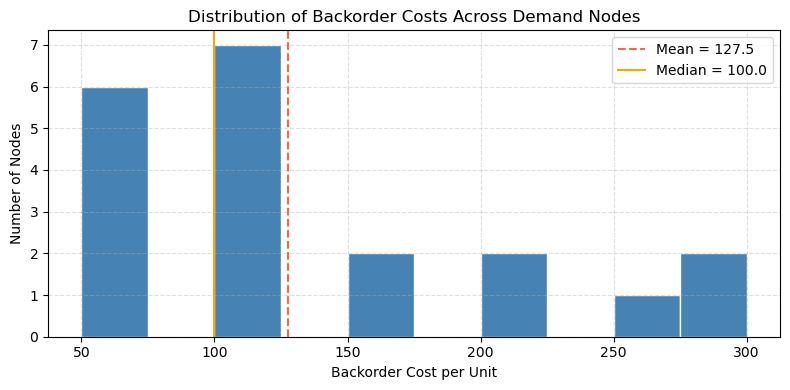

In [48]:
bc_nonzero = node_df[node_df["Layer"] == "D"]["BackorderCost"]
bc_nonzero = bc_nonzero[bc_nonzero > 0]

bc_mean = bc_nonzero.mean()
bc_median = bc_nonzero.median()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(bc_nonzero, bins=10, color='steelblue', edgecolor='white')
ax.axvline(bc_mean, color='tomato', linewidth=1.5, linestyle='--', label=f'Mean = {bc_mean:.1f}')
ax.axvline(bc_median, color='orange', linewidth=1.5, linestyle='-', label=f'Median = {bc_median:.1f}')
ax.set_xlabel("Backorder Cost per Unit")
ax.set_ylabel("Number of Nodes")
ax.set_title("Distribution of Backorder Costs Across Demand Nodes")
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


As shown, the service level, given the backorder costs, is solved to be optimal at >95%, which is what we expected given that most costs are higher than the shadow cost of $50 at that service level range.

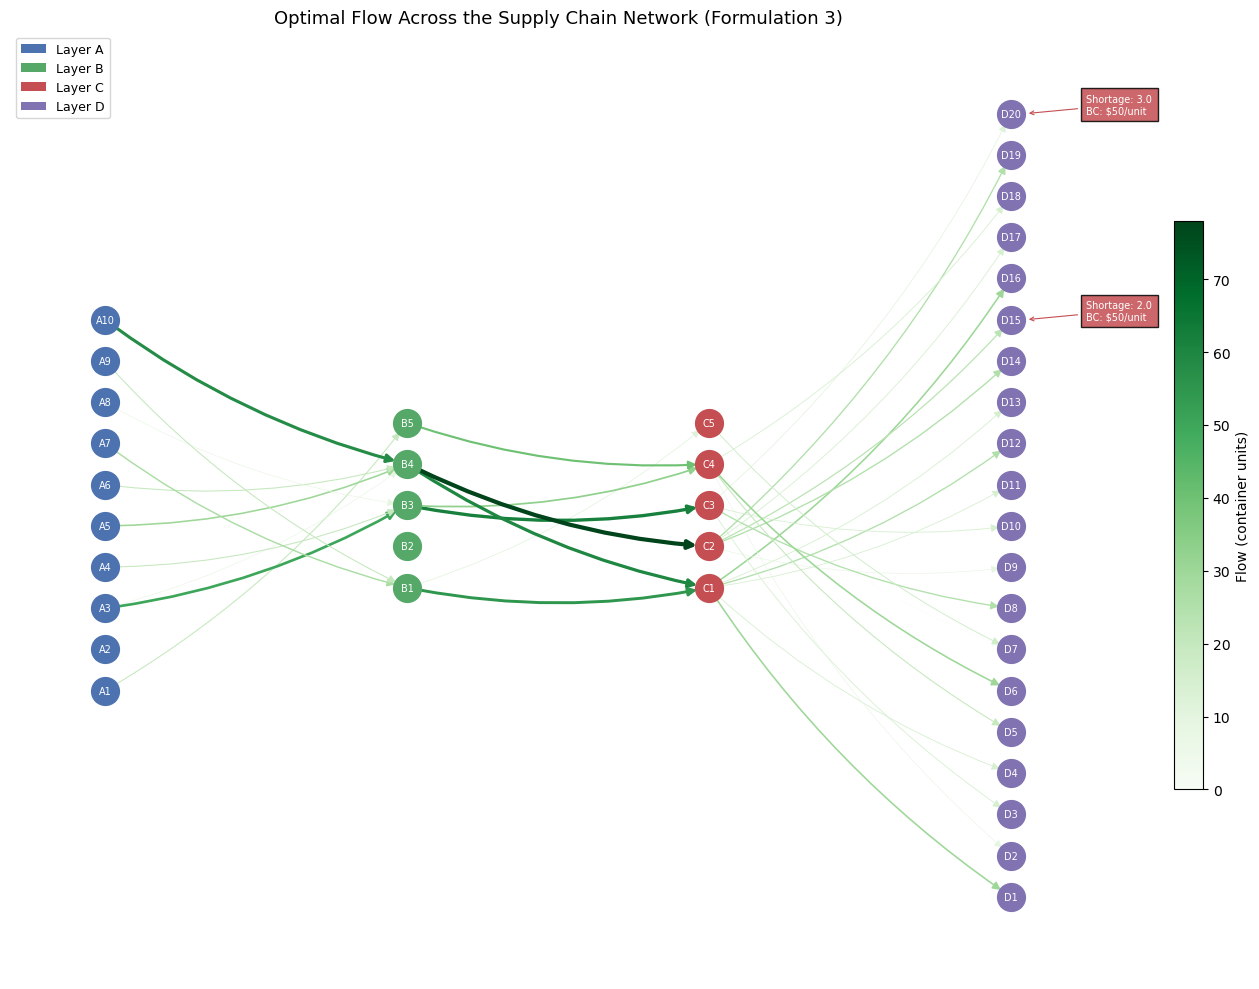

In [49]:
# Build graph from edges with non-zero flow
flow_values = {e: x[e].X for e in od_pairs if x[e].X > 1e-6}
G_viz = nx.DiGraph(flow_values.keys())
G_viz.add_nodes_from(nodes)

# Position nodes: x = layer index, y = rank within layer
layer_order = ['A', 'B', 'C', 'D']
layer_nodes = {l: sorted([n for n in nodes if n[0] == l], key=lambda n: int(n[1:])) for l in layer_order}
pos = {n: (layer_order.index(n[0]), layer_nodes[n[0]].index(n) - len(layer_nodes[n[0]]) / 2) for n in nodes}

# Edge styling scaled to flow
max_flow = max(flow_values.values(), default=1)
norm = mcolors.Normalize(vmin=0, vmax=max_flow)
edge_widths = [3 * flow_values[e] / max_flow for e in flow_values]
edge_colors = [cm.Greens(norm(flow_values[e])) for e in flow_values]

fig, ax = plt.subplots(figsize=(14, 10))

# Draw nodes and labels
layer_colors = {'A': '#4C72B0', 'B': '#55A868', 'C': '#C44E52', 'D': '#8172B2'}
for layer, color in layer_colors.items():
    nx.draw_networkx_nodes(G_viz, pos, nodelist=layer_nodes[layer], node_color=color, node_size=400, ax=ax)
nx.draw_networkx_labels(G_viz, pos, font_size=7, font_color='white', ax=ax)

# Draw edges
nx.draw_networkx_edges(G_viz, pos, edgelist=list(flow_values), width=edge_widths,
                       edge_color=edge_colors, arrows=True, arrowsize=12,
                       connectionstyle='arc3,rad=0.1', ax=ax)

# Annotate shortage amount and backorder cost for demand nodes with non-zero shortage
for n in demand_nodes:
    shortage = G[n].X
    if shortage > 1e-6:
        xp, yp = pos[n]
        bc = backorder_cost_dict[n]
        ax.annotate(
            f'Shortage: {shortage:.1f}\nBC: ${bc:.0f}/unit',
            xy=(xp + 0.05, yp),
            xytext=(xp + 0.25, yp),
            fontsize=7,
            color='white',
            bbox=dict(facecolor='#C44E52', alpha=0.85),
            arrowprops=dict(arrowstyle='->', lw=0.8, color='#C44E52'),
        )

# Legend and colorbar
ax.legend(handles=[Patch(facecolor=c, label=f'Layer {l}') for l, c in layer_colors.items()],
          loc='upper left', fontsize=9)
plt.colorbar(cm.ScalarMappable(cmap=cm.Greens, norm=norm), ax=ax,
             label='Flow (container units)', shrink=0.6)

ax.set_title('Optimal Flow Across the Supply Chain Network (Formulation 3)', fontsize=13)
ax.axis('off')
plt.tight_layout()
plt.show()

## Expanding the Supply Chain
As Forever 67 grows and scales in size, the management is looking to spend extra budget to improve and expand its supply chain. We can assess the three aspects of potential bottlenecks.
1. Transportation capacities
2. Inventories at nodes
3. Adding new edges between nodes

### Transportation Capacities

The shadow price on each capacity constraint x[t] <= u[t] equals the marginal reduction in cost per 1 unit of added capacity on that edge. Most negative shadow price = biggest bottleneck.

In [50]:
m_sens = Model()
m_sens.params.OutputFlag = 0

x_sens = m_sens.addVars(od_pairs, lb=0)
G_sens = m_sens.addVars(demand_nodes, lb=0)

# Explicit capacity constraints — required to read dual values
cap_constrs = {t: m_sens.addConstr(x_sens[t] <= capacity_dict[t]) for t in od_pairs}

for n in nodes:
    if n in demand_nodes:
        m_sens.addConstr(
            sum(x_sens[t] for t in od_pairs if t[0] == n) + demand_dict[n]
            <= sum(x_sens[t] for t in od_pairs if t[1] == n)
            + inventory_dict[n]
            + G_sens[n]
        )
    else:
        m_sens.addConstr(
            sum(x_sens[t] for t in od_pairs if t[0] == n) + demand_dict[n]
            <= sum(x_sens[t] for t in od_pairs if t[1] == n) + inventory_dict[n]
        )

m_sens.setObjective(
    sum(cost_dict[t] * x_sens[t] for t in od_pairs)
    + sum(backorder_cost_dict[n] * G_sens[n] for n in demand_nodes),
    GRB.MINIMIZE,
)
m_sens.optimize()

# Collect shadow prices and allowable increase (RHS ranging)
edge_shadow = {t: cap_constrs[t].Pi for t in od_pairs}
# .SARHSUp is the increase on the RHS (capacity) before the optimal basis changes.
edge_sar = {t: cap_constrs[t].SARHSUp for t in od_pairs}

bottleneck_sorted = sorted(
    [(t, edge_shadow[t], edge_sar[t]) for t in od_pairs if edge_shadow[t] < -1e-6],
    key=lambda kv: kv[1],
)  # shadow price with 0 have slack, so only consider negative shadow prices as bottlenecks

print(f"Bottleneck edges: {len(bottleneck_sorted)} / {len(od_pairs)}")

df_bottleneck = pd.DataFrame([
    {
        "Edge": f"{t[0]}→{t[1]}",
        "Shadow Price": round(sp, 2),
        "Capacity": int(capacity_dict[t]),
        "Allowable Increase": f"{sar:.1f}" if sar < 1e29 else "inf",
    }
    for t, sp, sar in bottleneck_sorted[:15]
])
df_bottleneck

Bottleneck edges: 3 / 103


,Edge,Shadow Price,Capacity,Allowable Increase
0,A3→B3,-10.0,50,60.0
1,B4→C2,-10.0,78,80.0
2,A10→B4,-5.0,58,60.0


As shown, we can get an appreciable amount of improvement in transportation cost, if we expand the capacity along those edges.

For B4→C2 for example, we can increase the capacity by 80, and we will save costs by 800. Beyond 80, we need to resolve the optimization to get an estimate.

Also note that the allowable increase analysis is only locally valid (single-edge, single-unit changes). If you want to evaluate expanding multiple edges simultaneously, we would need another formulation. Something like the following:

$$\begin{alignat}{2}
& \text{minimize} & \quad & \sum_{(i,j) \in \mathcal{E}} c_{i,j} x_{i,j} + \sum_{i \in \mathcal{N}_D} b_i G_i \\
& \text{subject to} & & \sum_{j \in \mathcal{N}: (j,i) \in \mathcal{E}} x_{j,i} + s_i + G_i \geq \sum_{j \in \mathcal{N}: (i,j) \in \mathcal{E}} x_{i,j} + d_i, \quad \forall \ i \in \mathcal{N}_D, \\
& & & \sum_{j \in \mathcal{N}: (j,i) \in \mathcal{E}} x_{j,i} + s_i \geq \sum_{j \in \mathcal{N}: (i,j) \in \mathcal{E}} x_{i,j} + d_i, \quad \forall \ i \in \mathcal{N} \setminus \mathcal{N}_D, \\
& & & x_{i,j} \leq u_{i,j} + \delta_{i,j}, \quad \forall\ (i,j), \\
& & & \sum_{(i,j)} \delta_{i,j} \leq B, \\
& & & \delta_{i,j} \geq 0, \\
& & & x_{i,j} \geq 0, \quad \forall\ (i,j) \in \mathcal{E}, \\
& & & G_i \geq 0, \quad \forall \ i \in \mathcal{N}_D. 
\end{alignat}$$

where 
- $B$ is the budget allocated to expanding transportation capacities, in units of transporation capacity.
- $\delta_{i,j}$ is the capacity additions

### Inventories at Nodes

Forever 67's management have decided that they have budget to increase the inventory at any of the nodes in manufacturing centers (layer A) by a total of
up to 50 units.

We will find 
1. where we can increase the inventory optimally
2. perform sensitivity analysis on the extent of inventory expansion

Let $\mathcal{N}_A$ denote the set of nodes in layer A, and let $Y_i$ be a continuous decision variable defined for each $i \in \mathcal{N}_A$ that indicates by how much the inventory in node $i$ should be increased. We also incorporate backorder costs as in Formulation 3, with shortfall variables $G_i$ for each demand node $i \in \mathcal{N}_D$.

The new problem is:

$$\begin{alignat}{2}
& \text{minimize} & \quad & \sum_{(i,j) \in \mathcal{E}} c_{i,j} x_{i,j} + \sum_{i \in \mathcal{N}_D} b_i G_i \\
& \text{subject to} & & \sum_{j \in \mathcal{N}: (j,i) \in \mathcal{E}} x_{j,i} + s_i + Y_i \geq \sum_{j \in \mathcal{N}: (i,j) \in \mathcal{E}} x_{i,j} + d_i, \quad \forall \ i \in \mathcal{N}_A, \\
& & & \sum_{j \in \mathcal{N}: (j,i) \in \mathcal{E}} x_{j,i} + s_i + G_i \geq \sum_{j \in \mathcal{N}: (i,j) \in \mathcal{E}} x_{i,j} + d_i, \quad \forall \ i \in \mathcal{N}_D, \\
& & & \sum_{j \in \mathcal{N}: (j,i) \in \mathcal{E}} x_{j,i} + s_i \geq \sum_{j \in \mathcal{N}: (i,j) \in \mathcal{E}} x_{i,j} + d_i, \quad \forall \ i \in \mathcal{N} \setminus (\mathcal{N}_A \cup \mathcal{N}_D), \\
& & & \sum_{i \in \mathcal{N}_A} Y_i \leq 50, \\
& & & x_{i,j} \leq u_{i,j}, \quad \forall\ (i,j) \in \mathcal{E}, \\
& & & x_{i,j} \geq 0, \quad \forall\ (i,j) \in \mathcal{E}, \\
& & & Y_i \geq 0, \quad \forall \ i \in \mathcal{N}_A, \\
& & & G_i \geq 0, \quad \forall \ i \in \mathcal{N}_D.
\end{alignat}$$

In [52]:
layer_A_nodes = [n for n in nodes if n[0] == "A"]
demand_nodes = [n for n in nodes if n[0] == "D"]

m_3b = Model()
m_3b.params.OutputFlag = 0

x = m_3b.addVars(od_pairs, lb=0, ub=capacity_dict)
Y = m_3b.addVars(layer_A_nodes, lb=0)
G = m_3b.addVars(demand_nodes, lb=0)

for n in nodes:
    if n in layer_A_nodes:
        m_3b.addConstr(
            sum(x[t] for t in od_pairs if t[0] == n) + demand_dict[n]
            <= sum(x[t] for t in od_pairs if t[1] == n) + inventory_dict[n] + Y[n]
        )
    elif n in demand_nodes:
        m_3b.addConstr(
            sum(x[t] for t in od_pairs if t[0] == n) + demand_dict[n]
            <= sum(x[t] for t in od_pairs if t[1] == n) + inventory_dict[n] + G[n]
        )
    else:
        m_3b.addConstr(
            sum(x[t] for t in od_pairs if t[0] == n) + demand_dict[n]
            <= sum(x[t] for t in od_pairs if t[1] == n) + inventory_dict[n]
        )

m_3b.addConstr(sum(Y[n] for n in layer_A_nodes) <= 50)

m_3b.setObjective(
    sum(cost_dict[t] * x[t] for t in od_pairs)
    + sum(backorder_cost_dict[n] * G[n] for n in demand_nodes),
    GRB.MINIMIZE,
)

m_3b.optimize()

total_shortfall = sum(G[n].X for n in demand_nodes)
total_demand = sum(demand_dict[n] for n in demand_nodes)
service_level = 1 - total_shortfall / total_demand

print(f"New optimal cost (inventory expansion): {m_3b.ObjVal:.2f}")
print(f"Optimal cost reduction: {(f3_cost - m_3b.ObjVal)/f3_cost:.2%}")
print(f"Total shortfall: {total_shortfall:.2f}")
print(f"Service level: {service_level:.2%}")
Y_nonzero = {n: round(Y[n].X, 2) for n in layer_A_nodes if Y[n].X > 1e-6}
print("Inventory additions (non-zero Y):", Y_nonzero)

New optimal cost (inventory expansion): 12005.00
Optimal cost reduction: 2.04%
Total shortfall: 17.00
Service level: 95.70%
Inventory additions (non-zero Y): {'A5': 18.0, 'A6': 32.0}


Now let's perform a sensitivity analysis.

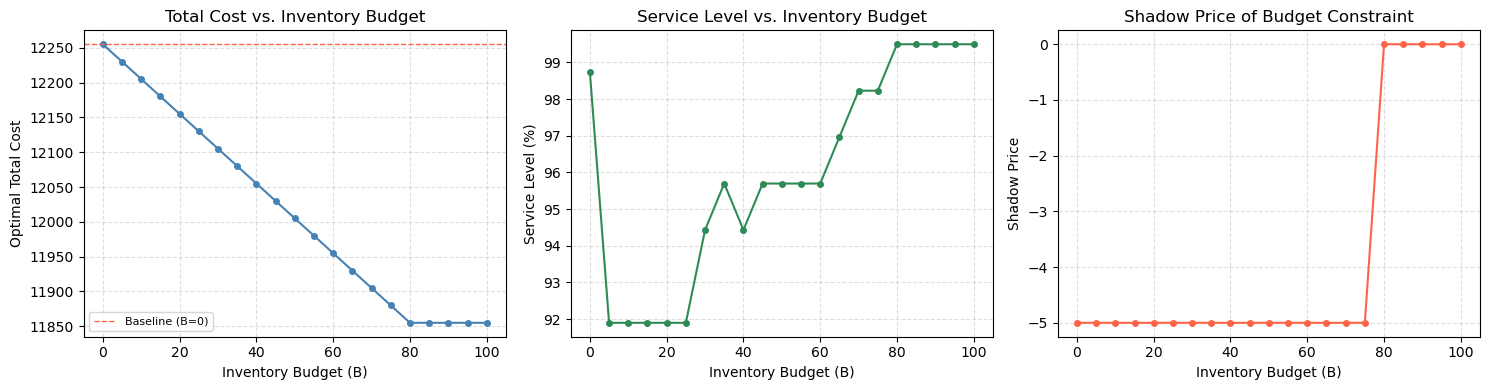

In [54]:
budget_range = range(0, 101, 5)
results = []

for B in budget_range:
    m_sa = Model()
    m_sa.params.OutputFlag = 0

    x_sa = m_sa.addVars(od_pairs, lb=0, ub=capacity_dict)
    Y_sa = m_sa.addVars(layer_A_nodes, lb=0)
    G_sa = m_sa.addVars(demand_nodes, lb=0)

    for n in nodes:
        if n in layer_A_nodes:
            m_sa.addConstr(
                sum(x_sa[t] for t in od_pairs if t[0] == n) + demand_dict[n]
                <= sum(x_sa[t] for t in od_pairs if t[1] == n) + inventory_dict[n] + Y_sa[n]
            )
        elif n in demand_nodes:
            m_sa.addConstr(
                sum(x_sa[t] for t in od_pairs if t[0] == n) + demand_dict[n]
                <= sum(x_sa[t] for t in od_pairs if t[1] == n) + inventory_dict[n] + G_sa[n]
            )
        else:
            m_sa.addConstr(
                sum(x_sa[t] for t in od_pairs if t[0] == n) + demand_dict[n]
                <= sum(x_sa[t] for t in od_pairs if t[1] == n) + inventory_dict[n]
            )

    budget_constr = m_sa.addConstr(sum(Y_sa[n] for n in layer_A_nodes) <= B)

    m_sa.setObjective(
        sum(cost_dict[t] * x_sa[t] for t in od_pairs)
        + sum(backorder_cost_dict[n] * G_sa[n] for n in demand_nodes),
        GRB.MINIMIZE,
    )
    m_sa.optimize()

    shortfall = sum(G_sa[n].X for n in demand_nodes)
    total_demand_val = sum(demand_dict[n] for n in demand_nodes)
    results.append({
        "Budget": B,
        "Optimal Cost": m_sa.ObjVal,
        "Cost Reduction (%)": (f3_cost - m_sa.ObjVal) / f3_cost * 100,
        "Service Level (%)": (1 - shortfall / total_demand_val) * 100,
        "Shadow Price (budget)": budget_constr.Pi,
    })

df_sa = pd.DataFrame(results).set_index("Budget")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(df_sa.index, df_sa["Optimal Cost"], color='steelblue', marker='o', markersize=4)
axes[0].axhline(f3_cost, color='tomato', linestyle='--', linewidth=1, label='Baseline (B=0)')
axes[0].set_xlabel("Inventory Budget (B)")
axes[0].set_ylabel("Optimal Total Cost")
axes[0].set_title("Total Cost vs. Inventory Budget")
axes[0].legend(fontsize=8)
axes[0].grid(True, linestyle='--', alpha=0.4)

axes[1].plot(df_sa.index, df_sa["Service Level (%)"], color='seagreen', marker='o', markersize=4)
axes[1].set_xlabel("Inventory Budget (B)")
axes[1].set_ylabel("Service Level (%)")
axes[1].set_title("Service Level vs. Inventory Budget")
axes[1].grid(True, linestyle='--', alpha=0.4)

axes[2].plot(df_sa.index, df_sa["Shadow Price (budget)"], color='tomato', marker='o', markersize=4)
axes[2].set_xlabel("Inventory Budget (B)")
axes[2].set_ylabel("Shadow Price")
axes[2].set_title("Shadow Price of Budget Constraint")
axes[2].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

As shown above, there comes a point where all the bottlenecks in the inventories are filled, and no longer contributes to lowering the optimal cost. Note that the above cost does not include the cost for expanding inventories, so a cost-benefit analysis should be performed there.

### Exploring New Edges
Forever 67's management would like to see whether opening up new routes (edges) between layers would help with lowering overall cost.

For example, we could add an edge from A1 to B3, as there is no edge between those two nodes. However, we cannot add an edge from A1 to C2, because these two nodes are not in adjacent layers.

The new edge would have a capacity of 50 units and unit cost of 5.

Let's first explore what edges can be opened up.

In [55]:
char_by_layer = ["A", "B", "C", "D"]
num_nodes_per_layer = [10, 5, 5, 20]

all_od_pairs = [
    (char_by_layer[ell] + str(i + 1), char_by_layer[ell + 1] + str(j + 1))
    for ell in range(3)
    for i in range(num_nodes_per_layer[ell])
    for j in range(num_nodes_per_layer[ell + 1])
]

new_od_pairs = [t for t in all_od_pairs if t not in od_pairs]

print("All od pairs:", len(all_od_pairs))
print("Existing od pairs:", len(od_pairs))
print("New od pairs:", len(new_od_pairs))

All od pairs: 175
Existing od pairs: 103
New od pairs: 72


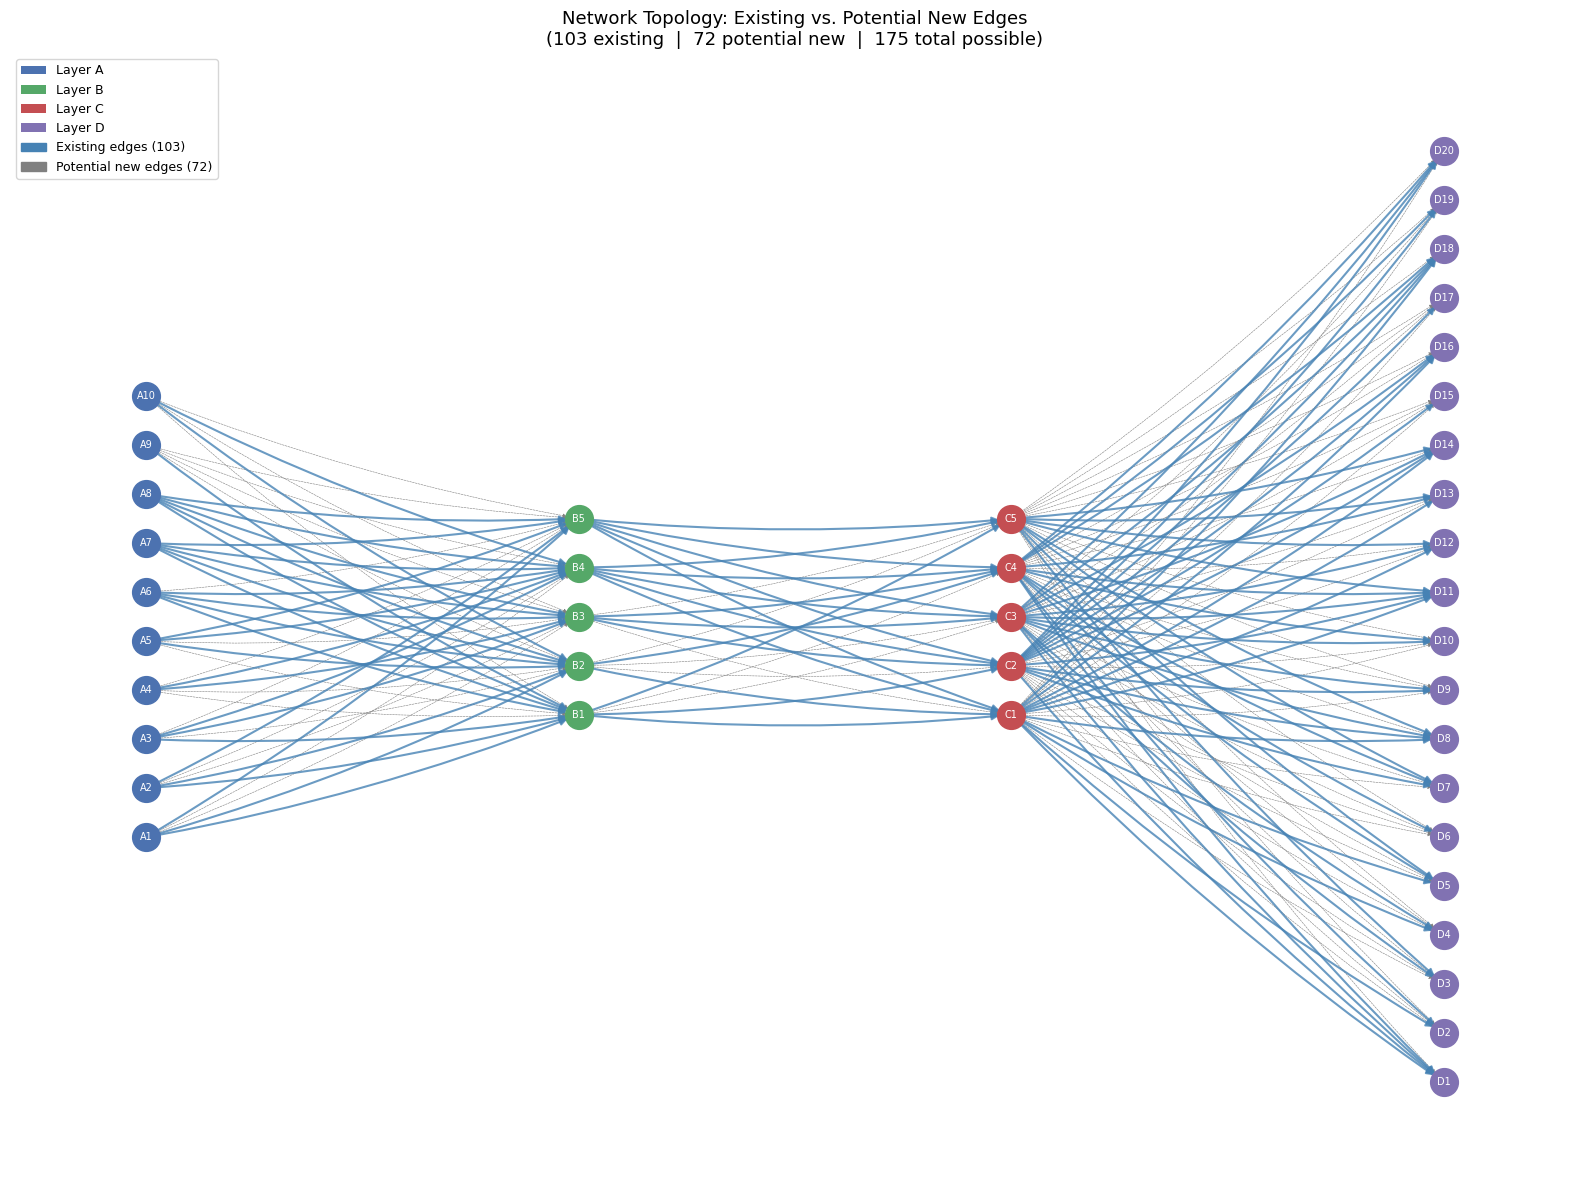

In [61]:
# Build graph containing ALL possible edges (existing + new)
G_all = nx.DiGraph()
G_all.add_nodes_from(nodes)
G_all.add_edges_from(all_od_pairs)

# Same positional layout as the rest of the notebook
layer_order = ['A', 'B', 'C', 'D']
layer_nodes_map = {
    l: sorted([n for n in nodes if n[0] == l], key=lambda n: int(n[1:]))
    for l in layer_order
}
pos = {
    n: (layer_order.index(n[0]), layer_nodes_map[n[0]].index(n) - len(layer_nodes_map[n[0]]) / 2)
    for n in nodes
}

layer_colors = {'A': '#4C72B0', 'B': '#55A868', 'C': '#C44E52', 'D': '#8172B2'}

fig, ax = plt.subplots(figsize=(16, 12))

# Draw nodes
for layer, color in layer_colors.items():
    nx.draw_networkx_nodes(G_all, pos, nodelist=layer_nodes_map[layer],
                           node_color=color, node_size=400, ax=ax)
nx.draw_networkx_labels(G_all, pos, font_size=7, font_color='white', ax=ax)

# Non-existing edges (gray, thin, transparent) — draw first so existing edges are on top
nx.draw_networkx_edges(
    G_all, pos, edgelist=new_od_pairs,
    width=0.4, alpha=1, edge_color='gray',
    arrows=True, arrowsize=6,
    connectionstyle='arc3,rad=0.05', ax=ax,
    style='dashed'
)

# Existing edges (blue, solid, more prominent)
nx.draw_networkx_edges(
    G_all, pos, edgelist=od_pairs,
    width=1.5, alpha=0.8, edge_color='steelblue',
    arrows=True, arrowsize=10,
    connectionstyle='arc3,rad=0.05', ax=ax
)

# Legend
legend_handles = [
    mpatches.Patch(facecolor=c, label=f'Layer {l}') for l, c in layer_colors.items()
]
legend_handles += [
    mpatches.Patch(color='steelblue', label=f'Existing edges ({len(od_pairs)})'),
    mpatches.Patch(color='gray',      label=f'Potential new edges ({len(new_od_pairs)})'),
]
ax.legend(handles=legend_handles, loc='upper left', fontsize=9)

ax.set_title(
    f'Network Topology: Existing vs. Potential New Edges\n'
    f'({len(od_pairs)} existing  |  {len(new_od_pairs)} potential new  |  '
    f'{len(all_od_pairs)} total possible)',
    fontsize=13
)
ax.axis('off')
plt.tight_layout()
plt.show()


This problem is more involved. Recall that $\mathcal{E}$ is the original set of edges. Let $\bar{\mathcal{E}}$ be the set of all edges between nodes in adjacent layers. Let $z_{i,j}$ be a binary variable that is 1 if edge $(i,j) \in \bar{\mathcal{E}} \setminus \mathcal{E}$ is added, and 0 otherwise. Additionally, redefine $x_{i,j}$ to be the flow along any edge $(i,j) \in \bar{\mathcal{E}}$. (Recall that previously, $x_{i,j}$ was only defined for edges in $\mathcal{E}$.)

Building on Formulation 3, we incorporate backorder costs and assign a unit transportation cost of 5 to any newly opened edge. The problem is:

$$\begin{alignat}{2}
& \text{minimize} & \quad & \sum_{(i,j) \in \mathcal{E}} c_{i,j} x_{i,j} + 5 \sum_{(i,j) \in \bar{\mathcal{E}} \setminus \mathcal{E}} x_{i,j} + \sum_{i \in \mathcal{N}_D} b_i G_i \\
& \text{subject to} & & \sum_{j \in \mathcal{N}: (j,i) \in \bar{\mathcal{E}}} x_{j,i} + s_i + G_i \geq \sum_{j \in \mathcal{N}: (i,j) \in \bar{\mathcal{E}}} x_{i,j} + d_i, \quad \forall \ i \in \mathcal{N}_D, \\
& & & \sum_{j \in \mathcal{N}: (j,i) \in \bar{\mathcal{E}}} x_{j,i} + s_i \geq \sum_{j \in \mathcal{N}: (i,j) \in \bar{\mathcal{E}}} x_{i,j} + d_i, \quad \forall \ i \in \mathcal{N} \setminus \mathcal{N}_D, \\
& & & x_{i,j} \leq u_{i,j}, \quad \forall\ (i,j) \in \mathcal{E}, \\
& & & x_{i,j} \leq 50 \cdot z_{i,j}, \quad \forall\ (i,j) \in \bar{\mathcal{E}} \setminus \mathcal{E}, \\
& & & \sum_{(i,j) \in \bar{\mathcal{E}} \setminus \mathcal{E}} z_{i,j} = 1, \\
& & & x_{i,j} \geq 0, \quad \forall\ (i,j) \in \bar{\mathcal{E}}, \\
& & & G_i \geq 0, \quad \forall \ i \in \mathcal{N}_D, \\
& & & z_{i,j} \in \{0,1\}, \quad \forall\ (i,j) \in \bar{\mathcal{E}} \setminus \mathcal{E}.
\end{alignat}$$

The first sum in the objective covers transportation on existing edges at their original costs; the second sum charges a unit cost of 5 for any flow routed through the newly opened edge; the third sum penalizes unmet demand via backorder costs as in Formulation 3.

In [64]:
demand_nodes = [n for n in nodes if n[0] == "D"]

m_3c = Model()
m_3c.params.OutputFlag = 0

x = m_3c.addVars(all_od_pairs, lb=0)
z = m_3c.addVars(new_od_pairs, vtype=GRB.BINARY)
G = m_3c.addVars(demand_nodes, lb=0)

# Flow balance — split for demand nodes (with G_i) and all others
for n in nodes:
    if n in demand_nodes:
        m_3c.addConstr(
            sum(x[t] for t in all_od_pairs if t[0] == n) + demand_dict[n]
            <= sum(x[t] for t in all_od_pairs if t[1] == n) + inventory_dict[n] + G[n]
        )
    else:
        m_3c.addConstr(
            sum(x[t] for t in all_od_pairs if t[0] == n) + demand_dict[n]
            <= sum(x[t] for t in all_od_pairs if t[1] == n) + inventory_dict[n]
        )

# Exactly one new edge is opened
m_3c.addConstr(sum(z[t] for t in new_od_pairs) == 1)

# Capacity constraints
for t in od_pairs:
    m_3c.addConstr(x[t] <= capacity_dict[t])
for t in new_od_pairs:
    m_3c.addConstr(x[t] <= 50 * z[t])

# Objective: transportation (existing) + transportation (new, unit cost 5) + backorder costs
m_3c.setObjective(
    sum(cost_dict[t] * x[t] for t in od_pairs)
    + 5 * sum(x[t] for t in new_od_pairs)
    + sum(backorder_cost_dict[n] * G[n] for n in demand_nodes),
    GRB.MINIMIZE,
)

m_3c.optimize()

print("New optimal cost (3c):", m_3c.objval)
print("Optimal cost reduction from 3b:", (f3_cost - m_3c.objval) / f3_cost * 100, "%")
edges_chosen = [t for t in new_od_pairs if z[t].x > 0.5]
print("Edge chosen for addition:", edges_chosen)

total_shortfall = sum(G[n].X for n in demand_nodes)
total_demand_val = sum(demand_dict[n] for n in demand_nodes)
print(f"Total shortfall: {total_shortfall:.2f}")
print(f"Service level: {1 - total_shortfall/total_demand_val:.2%}")

New optimal cost (3c): 11470.0
Optimal cost reduction from 3b: 6.405548755609955 %
Edge chosen for addition: [('B2', 'C5')]
Total shortfall: 2.00
Service level: 99.49%


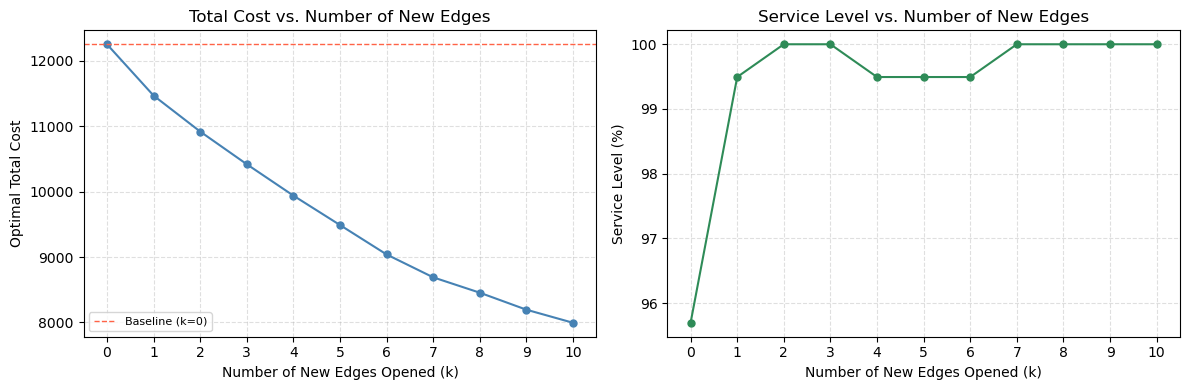

In [66]:
k_range = range(0, 11)
results_3c = []

for k in k_range:
    m_k = Model()
    m_k.params.OutputFlag = 0

    x_k = m_k.addVars(all_od_pairs, lb=0)
    z_k = m_k.addVars(new_od_pairs, vtype=GRB.BINARY)
    G_k = m_k.addVars(demand_nodes, lb=0)

    # Flow balance — split for demand nodes (with G_i) and all others
    for n in nodes:
        if n in demand_nodes:
            m_k.addConstr(
                sum(x_k[t] for t in all_od_pairs if t[0] == n) + demand_dict[n]
                <= sum(x_k[t] for t in all_od_pairs if t[1] == n) + inventory_dict[n] + G_k[n]
            )
        else:
            m_k.addConstr(
                sum(x_k[t] for t in all_od_pairs if t[0] == n) + demand_dict[n]
                <= sum(x_k[t] for t in all_od_pairs if t[1] == n) + inventory_dict[n]
            )

    # At most k new edges can be opened
    m_k.addConstr(sum(z_k[t] for t in new_od_pairs) <= k)

    # Capacity constraints
    for t in od_pairs:
        m_k.addConstr(x_k[t] <= capacity_dict[t])
    for t in new_od_pairs:
        m_k.addConstr(x_k[t] <= 50 * z_k[t])

    # Objective: existing transport + new edges at unit cost 5 + backorder costs
    m_k.setObjective(
        sum(cost_dict[t] * x_k[t] for t in od_pairs)
        + 5 * sum(x_k[t] for t in new_od_pairs)
        + sum(backorder_cost_dict[n] * G_k[n] for n in demand_nodes),
        GRB.MINIMIZE,
    )
    m_k.optimize()

    shortfall_k = sum(G_k[n].X for n in demand_nodes)
    total_demand_val = sum(demand_dict[n] for n in demand_nodes)
    edges_added = [t for t in new_od_pairs if z_k[t].X > 0.5]

    results_3c.append({
        "# New Edges": k,
        "Optimal Cost": m_k.ObjVal,
        "Cost Reduction (%)": (f3_cost - m_k.ObjVal) / f3_cost * 100,
        "Service Level (%)": (1 - shortfall_k / total_demand_val) * 100,
        "Edges Added": edges_added,
    })

df_3c = pd.DataFrame(results_3c).set_index("# New Edges")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(df_3c.index, df_3c["Optimal Cost"], color='steelblue', marker='o', markersize=5)
axes[0].axhline(f3_cost, color='tomato', linestyle='--', linewidth=1, label='Baseline (k=0)')
axes[0].set_xlabel("Number of New Edges Opened (k)")
axes[0].set_ylabel("Optimal Total Cost")
axes[0].set_title("Total Cost vs. Number of New Edges")
axes[0].set_xticks(list(k_range))
axes[0].legend(fontsize=8)
axes[0].grid(True, linestyle='--', alpha=0.4)

axes[1].plot(df_3c.index, df_3c["Service Level (%)"], color='seagreen', marker='o', markersize=5)
axes[1].set_xlabel("Number of New Edges Opened (k)")
axes[1].set_ylabel("Service Level (%)")
axes[1].set_title("Service Level vs. Number of New Edges")
axes[1].set_xticks(list(k_range))
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

## Simulating Supply Chain Disruptions

Let’s now consider the following scenarios for how the supply chain network might be disrupted.

1. Suppose that we reduce the available inventory at every node by p × 100%. For example, if p = 0.05, and the nominal inventory at node i is Si, then node i’s inventory would be reduced by 5%, i.e., it would now have (1 −p)×Si = 0.95Si container units of inventory.
2. We conduct the same analysis to disruption for transport capacities.
2. Some routes (edges) might become dysfunctional under certain circumstances such as natural disasters. We calculate the cost when an entire edge fails, and seeks to identify the most vulnerable edges.
3. Some nodes might become dysfunctional.

### Scenario 1: Inventory Shortage

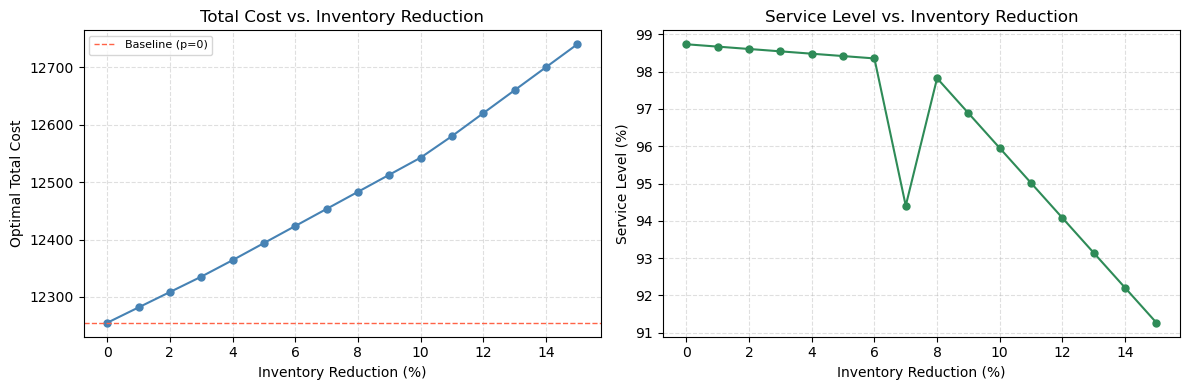

In [68]:
p_list = [p / 100 for p in range(0, 16)]  # 0%, 1%, ..., 15%
results_s1 = []

for p in p_list:
    # Scale down inventory at every node by (1 - p)
    disrupted_inventory = {n: inventory_dict[n] * (1 - p) for n in nodes}

    m_s1 = Model()
    m_s1.params.OutputFlag = 0

    x_s1 = m_s1.addVars(od_pairs, lb=0, ub=capacity_dict)
    G_s1 = m_s1.addVars(demand_nodes, lb=0)

    for n in nodes:
        if n in demand_nodes:
            m_s1.addConstr(
                sum(x_s1[t] for t in od_pairs if t[0] == n) + demand_dict[n]
                <= sum(x_s1[t] for t in od_pairs if t[1] == n) + disrupted_inventory[n] + G_s1[n]
            )
        else:
            m_s1.addConstr(
                sum(x_s1[t] for t in od_pairs if t[0] == n) + demand_dict[n]
                <= sum(x_s1[t] for t in od_pairs if t[1] == n) + disrupted_inventory[n]
            )

    m_s1.setObjective(
        sum(cost_dict[t] * x_s1[t] for t in od_pairs)
        + sum(backorder_cost_dict[n] * G_s1[n] for n in demand_nodes),
        GRB.MINIMIZE,
    )
    m_s1.optimize()

    shortfall = sum(G_s1[n].X for n in demand_nodes)
    total_demand_val = sum(demand_dict[n] for n in demand_nodes)
    results_s1.append({
        "p": p,
        "Optimal Cost": m_s1.ObjVal,
        "Cost Increase (%)": (m_s1.ObjVal - f3_cost) / f3_cost * 100,
        "Service Level (%)": (1 - shortfall / total_demand_val) * 100,
    })

df_s1 = pd.DataFrame(results_s1).set_index("p")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(df_s1.index * 100, df_s1["Optimal Cost"], color='steelblue', marker='o', markersize=5)
axes[0].axhline(f3_cost, color='tomato', linestyle='--', linewidth=1, label='Baseline (p=0)')
axes[0].set_xlabel("Inventory Reduction (%)")
axes[0].set_ylabel("Optimal Total Cost")
axes[0].set_title("Total Cost vs. Inventory Reduction")
axes[0].legend(fontsize=8)
axes[0].grid(True, linestyle='--', alpha=0.4)

axes[1].plot(df_s1.index * 100, df_s1["Service Level (%)"], color='seagreen', marker='o', markersize=5)
axes[1].set_xlabel("Inventory Reduction (%)")
axes[1].set_ylabel("Service Level (%)")
axes[1].set_title("Service Level vs. Inventory Reduction")
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

### Scenario 2: Tranport Capacity Disruption

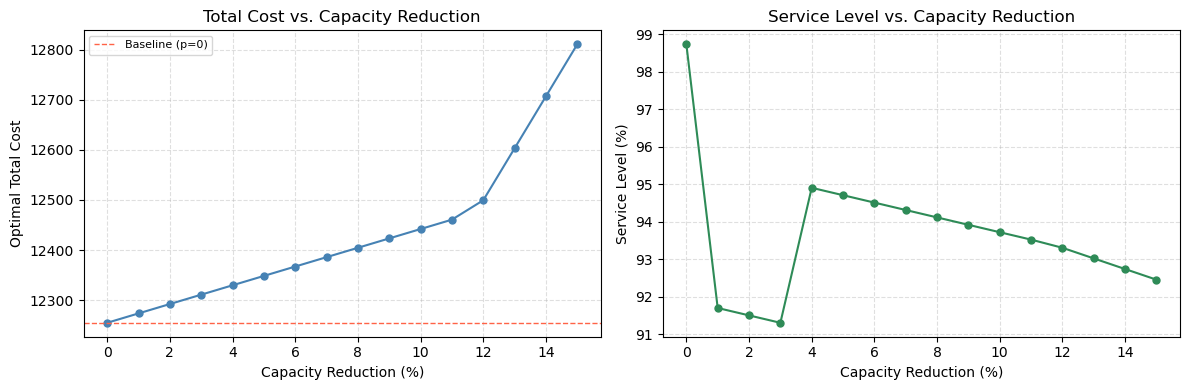

In [71]:
p_list = [p / 100 for p in range(0, 16)]  # 0%, 1%, ..., 15%
results_s2 = []

for p in p_list:
    # Scale down every edge capacity by (1 - p)
    disrupted_capacity = {t: capacity_dict[t] * (1 - p) for t in od_pairs}

    m_s2 = Model()
    m_s2.params.OutputFlag = 0

    x_s2 = m_s2.addVars(od_pairs, lb=0, ub=disrupted_capacity)
    G_s2 = m_s2.addVars(demand_nodes, lb=0)

    for n in nodes:
        if n in demand_nodes:
            m_s2.addConstr(
                sum(x_s2[t] for t in od_pairs if t[0] == n) + demand_dict[n]
                <= sum(x_s2[t] for t in od_pairs if t[1] == n) + inventory_dict[n] + G_s2[n]
            )
        else:
            m_s2.addConstr(
                sum(x_s2[t] for t in od_pairs if t[0] == n) + demand_dict[n]
                <= sum(x_s2[t] for t in od_pairs if t[1] == n) + inventory_dict[n]
            )

    m_s2.setObjective(
        sum(cost_dict[t] * x_s2[t] for t in od_pairs)
        + sum(backorder_cost_dict[n] * G_s2[n] for n in demand_nodes),
        GRB.MINIMIZE,
    )
    m_s2.optimize()

    shortfall = sum(G_s2[n].X for n in demand_nodes)
    total_demand_val = sum(demand_dict[n] for n in demand_nodes)
    results_s2.append({
        "p": p,
        "Optimal Cost": m_s2.ObjVal,
        "Cost Increase (%)": (m_s2.ObjVal - f3_cost) / f3_cost * 100,
        "Service Level (%)": (1 - shortfall / total_demand_val) * 100,
    })

df_s2 = pd.DataFrame(results_s2).set_index("p")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(df_s2.index * 100, df_s2["Optimal Cost"], color='steelblue', marker='o', markersize=5)
axes[0].axhline(f3_cost, color='tomato', linestyle='--', linewidth=1, label='Baseline (p=0)')
axes[0].set_xlabel("Capacity Reduction (%)")
axes[0].set_ylabel("Optimal Total Cost")
axes[0].set_title("Total Cost vs. Capacity Reduction")
axes[0].legend(fontsize=8)
axes[0].grid(True, linestyle='--', alpha=0.4)

axes[1].plot(df_s2.index * 100, df_s2["Service Level (%)"], color='seagreen', marker='o', markersize=5)
axes[1].set_xlabel("Capacity Reduction (%)")
axes[1].set_ylabel("Service Level (%)")
axes[1].set_title("Service Level vs. Capacity Reduction")
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

### Scenario 3: Edges Failure

Top 10 most vulnerable edges (by cost increase when failed):
     Edge    Cost  Cost Increase  Cost Increase (%)  Service Level (%)
 (C4, D6) 19755.0         7500.0          61.199510          90.632911
 (B4, C2) 13310.0         1055.0           8.608731          89.873418
(C2, D17) 13155.0          900.0           7.343941          95.696203
 (A3, B3) 12755.0          500.0           4.079967          95.696203
(A10, B4) 12740.0          485.0           3.957568          88.101266
(C1, D12) 12630.0          375.0           3.059976          87.594937
 (B1, C1) 12555.0          300.0           2.447980          88.101266
 (C1, D1) 12555.0          300.0           2.447980          95.696203
 (B4, C1) 12515.0          260.0           2.121583          99.240506
 (A5, B4) 12460.0          205.0           1.672787          95.949367


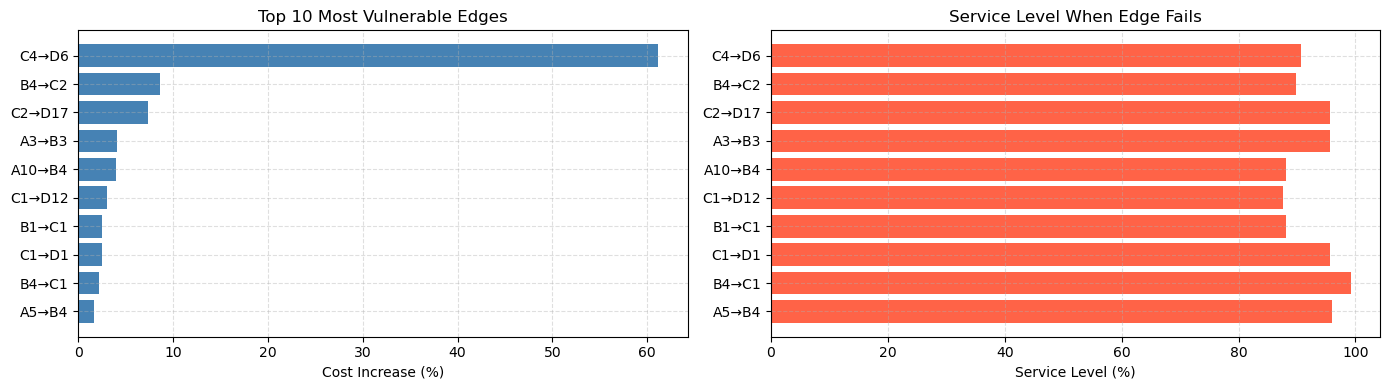

In [73]:
results_edge_fail = []

for failed_edge in od_pairs:
    # Build fresh Formulation 3 model with the failed edge capacity set to 0
    disrupted_cap = {t: (0 if t == failed_edge else capacity_dict[t]) for t in od_pairs}

    m_ef = Model()
    m_ef.params.OutputFlag = 0

    x_ef = m_ef.addVars(od_pairs, lb=0, ub=disrupted_cap)
    G_ef = m_ef.addVars(demand_nodes, lb=0)

    for n in nodes:
        if n in demand_nodes:
            m_ef.addConstr(
                sum(x_ef[t] for t in od_pairs if t[0] == n) + demand_dict[n]
                <= sum(x_ef[t] for t in od_pairs if t[1] == n) + inventory_dict[n] + G_ef[n]
            )
        else:
            m_ef.addConstr(
                sum(x_ef[t] for t in od_pairs if t[0] == n) + demand_dict[n]
                <= sum(x_ef[t] for t in od_pairs if t[1] == n) + inventory_dict[n]
            )

    m_ef.setObjective(
        sum(cost_dict[t] * x_ef[t] for t in od_pairs)
        + sum(backorder_cost_dict[n] * G_ef[n] for n in demand_nodes),
        GRB.MINIMIZE,
    )
    m_ef.optimize()

    shortfall = sum(G_ef[n].X for n in demand_nodes)
    total_demand_val = sum(demand_dict[n] for n in demand_nodes)
    results_edge_fail.append({
        "Edge": failed_edge,
        "Cost": m_ef.ObjVal,
        "Cost Increase": m_ef.ObjVal - f3_cost,
        "Cost Increase (%)": (m_ef.ObjVal - f3_cost) / f3_cost * 100,
        "Service Level (%)": (1 - shortfall / total_demand_val) * 100,
    })

df_edge_fail = (
    pd.DataFrame(results_edge_fail)
    .sort_values("Cost Increase", ascending=False)
    .reset_index(drop=True)
)

# Show top 10 most vulnerable edges
top_n = 10
print(f"Top {top_n} most vulnerable edges (by cost increase when failed):")
print(df_edge_fail.head(top_n).to_string(index=False))

# Bar chart of top vulnerable edges
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

top_df = df_edge_fail.head(top_n).copy()
top_df["Edge Label"] = top_df["Edge"].apply(lambda t: f"{t[0]}→{t[1]}")

axes[0].barh(top_df["Edge Label"][::-1], top_df["Cost Increase (%)"][::-1], color="steelblue")
axes[0].set_xlabel("Cost Increase (%)")
axes[0].set_title(f"Top {top_n} Most Vulnerable Edges")
axes[0].grid(True, linestyle="--", alpha=0.4)

axes[1].barh(top_df["Edge Label"][::-1], top_df["Service Level (%)"][::-1], color="tomato")
axes[1].set_xlabel("Service Level (%)")
axes[1].set_title(f"Service Level When Edge Fails")
axes[1].grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

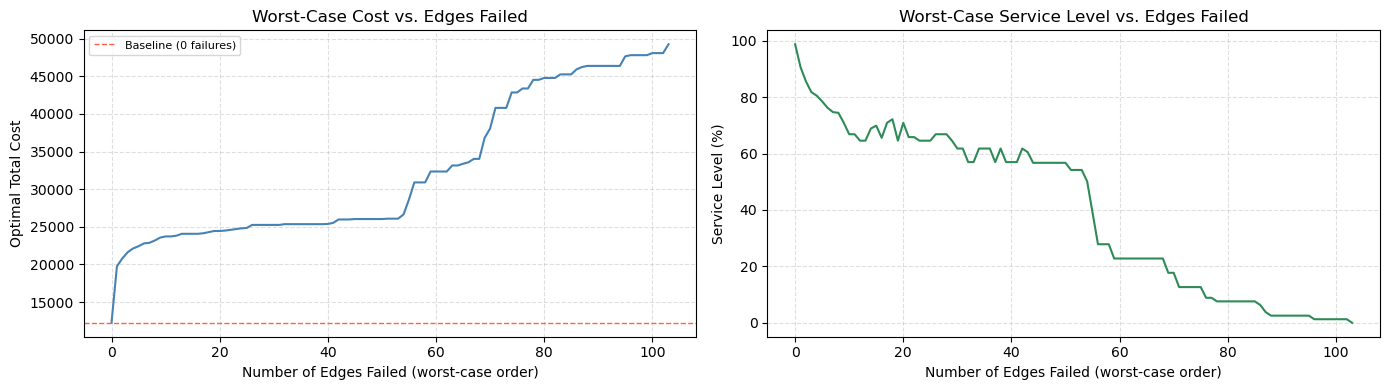

In [74]:
# Worst-case cascade: fail edges in order of individual vulnerability (most → least)
# At step k, the k most vulnerable edges are simultaneously removed.
vulnerability_order = df_edge_fail["Edge"].tolist()  # already sorted most → least vulnerable

results_cascade = []
for k in range(len(vulnerability_order) + 1):
    failed_set = set(vulnerability_order[:k])
    disrupted_cap = {t: (0 if t in failed_set else capacity_dict[t]) for t in od_pairs}

    m_cas = Model()
    m_cas.params.OutputFlag = 0

    x_cas = m_cas.addVars(od_pairs, lb=0, ub=disrupted_cap)
    G_cas = m_cas.addVars(demand_nodes, lb=0)

    for n in nodes:
        if n in demand_nodes:
            m_cas.addConstr(
                sum(x_cas[t] for t in od_pairs if t[0] == n) + demand_dict[n]
                <= sum(x_cas[t] for t in od_pairs if t[1] == n) + inventory_dict[n] + G_cas[n]
            )
        else:
            m_cas.addConstr(
                sum(x_cas[t] for t in od_pairs if t[0] == n) + demand_dict[n]
                <= sum(x_cas[t] for t in od_pairs if t[1] == n) + inventory_dict[n]
            )

    m_cas.setObjective(
        sum(cost_dict[t] * x_cas[t] for t in od_pairs)
        + sum(backorder_cost_dict[n] * G_cas[n] for n in demand_nodes),
        GRB.MINIMIZE,
    )
    m_cas.optimize()

    shortfall = sum(G_cas[n].X for n in demand_nodes)
    total_demand_val = sum(demand_dict[n] for n in demand_nodes)
    results_cascade.append({
        "Edges Failed": k,
        "Optimal Cost": m_cas.ObjVal,
        "Cost Increase (%)": (m_cas.ObjVal - f3_cost) / f3_cost * 100,
        "Service Level (%)": (1 - shortfall / total_demand_val) * 100,
    })

df_cascade = pd.DataFrame(results_cascade).set_index("Edges Failed")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(df_cascade.index, df_cascade["Optimal Cost"], color='steelblue', linewidth=1.5)
axes[0].axhline(f3_cost, color='tomato', linestyle='--', linewidth=1, label='Baseline (0 failures)')
axes[0].set_xlabel("Number of Edges Failed (worst-case order)")
axes[0].set_ylabel("Optimal Total Cost")
axes[0].set_title("Worst-Case Cost vs. Edges Failed")
axes[0].legend(fontsize=8)
axes[0].grid(True, linestyle='--', alpha=0.4)

axes[1].plot(df_cascade.index, df_cascade["Service Level (%)"], color='seagreen', linewidth=1.5)
axes[1].set_xlabel("Number of Edges Failed (worst-case order)")
axes[1].set_ylabel("Service Level (%)")
axes[1].set_title("Worst-Case Service Level vs. Edges Failed")
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

We are experiencing a jump at ~50 edges, and this is likely because the ranking was calculated at the local level, where there is no disruption. To get a true worst-case disruption scenario, we will deploy a greedy algorithm like below.

Step 0: baseline cost = 12255.00
Step   1: remove ('C4', 'D6')  →  cost = 19755.00  (+61.2%)  SL = 90.6%
Step   2: remove ('B4', 'C2')  →  cost = 20810.00  (+69.8%)  SL = 85.6%
Step   3: remove ('C2', 'D17')  →  cost = 21635.00  (+76.5%)  SL = 81.8%
Step   4: remove ('A3', 'B3')  →  cost = 22135.00  (+80.6%)  SL = 80.5%
Step   5: remove ('C1', 'D12')  →  cost = 22510.00  (+83.7%)  SL = 78.7%
Step   6: remove ('C1', 'D1')  →  cost = 22810.00  (+86.1%)  SL = 73.4%
Step   7: remove ('A10', 'B4')  →  cost = 23100.00  (+88.5%)  SL = 72.2%
Step   8: remove ('A5', 'B4')  →  cost = 23250.00  (+89.7%)  SL = 72.2%
Step   9: remove ('B1', 'C1')  →  cost = 23480.00  (+91.6%)  SL = 71.9%
Step  10: remove ('B4', 'C1')  →  cost = 23725.00  (+93.6%)  SL = 66.8%
Step  11: remove ('C3', 'D8')  →  cost = 23975.00  (+95.6%)  SL = 70.9%
Step  12: remove ('B1', 'C5')  →  cost = 24205.00  (+97.5%)  SL = 61.8%
Step  13: remove ('A3', 'B4')  →  cost = 24425.00  (+99.3%)  SL = 58.2%
Step  14: remove ('A1', 'B5'

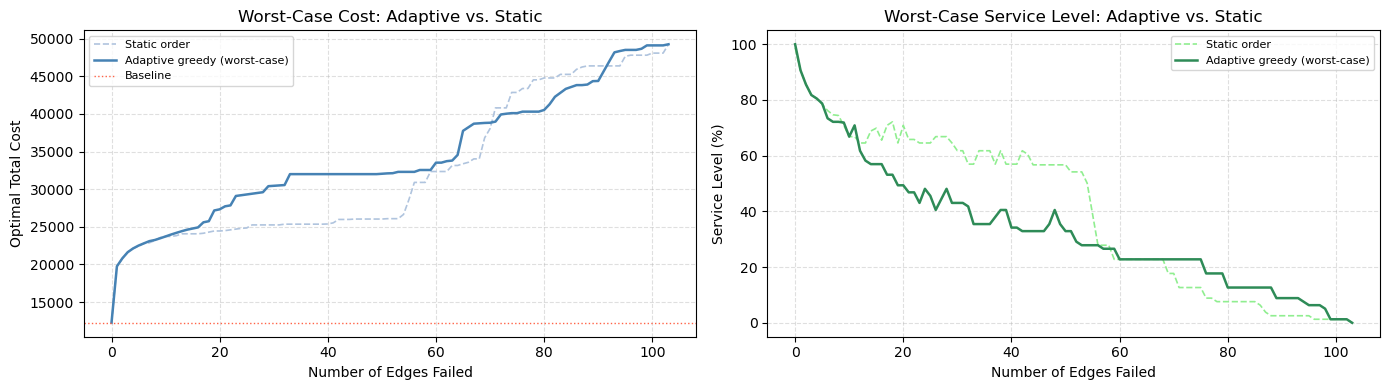

In [75]:
def solve_f3(failed_set):
    """Solve Formulation 3 with edges in failed_set having capacity 0. Returns (cost, service_level)."""
    disrupted_cap = {t: (0 if t in failed_set else capacity_dict[t]) for t in od_pairs}
    m_ = Model()
    m_.params.OutputFlag = 0
    x_ = m_.addVars(od_pairs, lb=0, ub=disrupted_cap)
    G_ = m_.addVars(demand_nodes, lb=0)
    for n in nodes:
        if n in demand_nodes:
            m_.addConstr(
                sum(x_[t] for t in od_pairs if t[0] == n) + demand_dict[n]
                <= sum(x_[t] for t in od_pairs if t[1] == n) + inventory_dict[n] + G_[n]
            )
        else:
            m_.addConstr(
                sum(x_[t] for t in od_pairs if t[0] == n) + demand_dict[n]
                <= sum(x_[t] for t in od_pairs if t[1] == n) + inventory_dict[n]
            )
    m_.setObjective(
        sum(cost_dict[t] * x_[t] for t in od_pairs)
        + sum(backorder_cost_dict[n] * G_[n] for n in demand_nodes),
        GRB.MINIMIZE,
    )
    m_.optimize()
    shortfall = sum(G_[n].X for n in demand_nodes)
    total_demand_val = sum(demand_dict[n] for n in demand_nodes)
    sl = (1 - shortfall / total_demand_val) * 100
    return m_.ObjVal, sl


# Adaptive greedy: at each step, find which remaining edge causes the MOST damage NOW
failed_set = set()
remaining = list(od_pairs)

results_adaptive = [{"Edges Failed": 0, "Optimal Cost": f3_cost, "Cost Increase (%)": 0.0,
                     "Service Level (%)": 100.0, "Edge Removed": None}]

print(f"Step 0: baseline cost = {f3_cost:.2f}")

for step in range(1, len(od_pairs) + 1):
    best_edge, best_cost = None, -1
    for candidate in remaining:
        cost, _ = solve_f3(failed_set | {candidate})
        if cost > best_cost:
            best_cost, best_edge = cost, candidate

    failed_set.add(best_edge)
    remaining.remove(best_edge)
    cost, sl = solve_f3(failed_set)

    results_adaptive.append({
        "Edges Failed": step,
        "Optimal Cost": cost,
        "Cost Increase (%)": (cost - f3_cost) / f3_cost * 100,
        "Service Level (%)": sl,
        "Edge Removed": best_edge,
    })
    print(f"Step {step:3d}: remove {best_edge}  →  cost = {cost:.2f}  (+{(cost-f3_cost)/f3_cost*100:.1f}%)  SL = {sl:.1f}%")

    # Stop early once service level hits 0
    if sl <= 0:
        print("Service level reached 0%. Stopping early.")
        break

df_adaptive = pd.DataFrame(results_adaptive).set_index("Edges Failed")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Also plot the static cascade for comparison
static_idx = df_cascade.index[:len(df_adaptive)]
axes[0].plot(static_idx, df_cascade.loc[static_idx, "Optimal Cost"],
             color='lightsteelblue', linewidth=1.2, linestyle='--', label='Static order')
axes[0].plot(df_adaptive.index, df_adaptive["Optimal Cost"],
             color='steelblue', linewidth=1.8, label='Adaptive greedy (worst-case)')
axes[0].axhline(f3_cost, color='tomato', linestyle=':', linewidth=1, label='Baseline')
axes[0].set_xlabel("Number of Edges Failed")
axes[0].set_ylabel("Optimal Total Cost")
axes[0].set_title("Worst-Case Cost: Adaptive vs. Static")
axes[0].legend(fontsize=8)
axes[0].grid(True, linestyle='--', alpha=0.4)

axes[1].plot(static_idx, df_cascade.loc[static_idx, "Service Level (%)"],
             color='lightgreen', linewidth=1.2, linestyle='--', label='Static order')
axes[1].plot(df_adaptive.index, df_adaptive["Service Level (%)"],
             color='seagreen', linewidth=1.8, label='Adaptive greedy (worst-case)')
axes[1].set_xlabel("Number of Edges Failed")
axes[1].set_ylabel("Service Level (%)")
axes[1].set_title("Worst-Case Service Level: Adaptive vs. Static")
axes[1].legend(fontsize=8)
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


### Scenario 4: Nodes Failure

Step 0: baseline cost = 12255.00
Step   1: remove C4  →  cost = 20110.00  (+64.1%)  SL = 88.1%
Step   2: remove C2  →  cost = 24165.00  (+97.2%)  SL = 75.9%
Step   3: remove C3  →  cost = 28500.00  (+132.6%)  SL = 65.8%
Step   4: remove C1  →  cost = 32895.00  (+168.4%)  SL = 40.5%
Step   5: remove C5  →  cost = 49250.00  (+301.9%)  SL = 0.0%
Service level reached 0%. Stopping early.


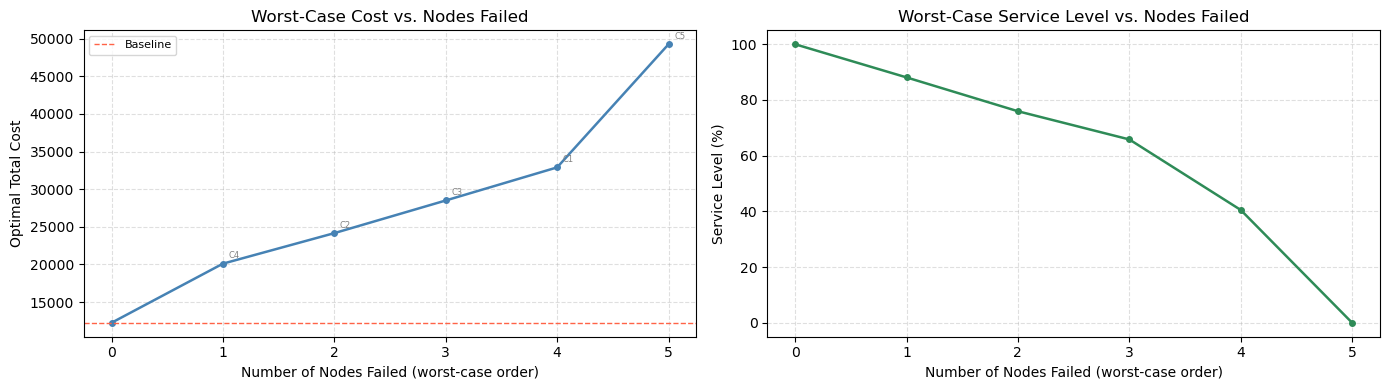

In [77]:
def solve_f3_node_fail(failed_nodes):
    """Solve Formulation 3 with all edges incident to any failed node having capacity 0."""
    disrupted_cap = {
        t: (0 if (t[0] in failed_nodes or t[1] in failed_nodes) else capacity_dict[t])
        for t in od_pairs
    }
    m_ = Model()
    m_.params.OutputFlag = 0
    x_ = m_.addVars(od_pairs, lb=0, ub=disrupted_cap)
    G_ = m_.addVars(demand_nodes, lb=0)
    for n in nodes:
        if n in failed_nodes:
            # Failed node: force zero in/out flow via capacity=0; no flow balance needed
            continue
        if n in demand_nodes:
            m_.addConstr(
                sum(x_[t] for t in od_pairs if t[0] == n) + demand_dict[n]
                <= sum(x_[t] for t in od_pairs if t[1] == n) + inventory_dict[n] + G_[n]
            )
        else:
            m_.addConstr(
                sum(x_[t] for t in od_pairs if t[0] == n) + demand_dict[n]
                <= sum(x_[t] for t in od_pairs if t[1] == n) + inventory_dict[n]
            )
    m_.setObjective(
        sum(cost_dict[t] * x_[t] for t in od_pairs)
        + sum(backorder_cost_dict[n] * G_[n] for n in demand_nodes if n not in failed_nodes),
        GRB.MINIMIZE,
    )
    m_.optimize()
    # Demand nodes that failed contribute their full demand as unmet
    active_demand = sum(demand_dict[n] for n in demand_nodes if n not in failed_nodes)
    failed_demand = sum(demand_dict[n] for n in demand_nodes if n in failed_nodes)
    shortfall_active = sum(G_[n].X for n in demand_nodes if n not in failed_nodes)
    total_unmet = shortfall_active + failed_demand
    total_demand_val = sum(demand_dict[n] for n in demand_nodes)
    sl = (1 - total_unmet / total_demand_val) * 100
    return m_.ObjVal, sl


# Adaptive greedy worst-case for node failures
failed_nodes_set = set()
remaining_nodes = list(nodes)

results_node_adaptive = [{"Nodes Failed": 0, "Optimal Cost": f3_cost, "Cost Increase (%)": 0.0,
                           "Service Level (%)": 100.0, "Node Removed": None}]

print(f"Step 0: baseline cost = {f3_cost:.2f}")

for step in range(1, len(nodes) + 1):
    best_node, best_cost = None, -1
    for candidate in remaining_nodes:
        cost, _ = solve_f3_node_fail(failed_nodes_set | {candidate})
        if cost > best_cost:
            best_cost, best_node = cost, candidate

    failed_nodes_set.add(best_node)
    remaining_nodes.remove(best_node)
    cost, sl = solve_f3_node_fail(failed_nodes_set)

    results_node_adaptive.append({
        "Nodes Failed": step,
        "Optimal Cost": cost,
        "Cost Increase (%)": (cost - f3_cost) / f3_cost * 100,
        "Service Level (%)": sl,
        "Node Removed": best_node,
    })
    print(f"Step {step:3d}: remove {best_node}  →  cost = {cost:.2f}  (+{(cost-f3_cost)/f3_cost*100:.1f}%)  SL = {sl:.1f}%")

    if sl <= 0:
        print("Service level reached 0%. Stopping early.")
        break

df_node_adaptive = pd.DataFrame(results_node_adaptive).set_index("Nodes Failed")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(df_node_adaptive.index, df_node_adaptive["Optimal Cost"],
             color='steelblue', linewidth=1.8, marker='o', markersize=4)
axes[0].axhline(f3_cost, color='tomato', linestyle='--', linewidth=1, label='Baseline')
axes[0].set_xlabel("Number of Nodes Failed (worst-case order)")
axes[0].set_ylabel("Optimal Total Cost")
axes[0].set_title("Worst-Case Cost vs. Nodes Failed")
axes[0].legend(fontsize=8)
axes[0].grid(True, linestyle='--', alpha=0.4)

# Annotate which node was removed at each step
for _, row in df_node_adaptive.dropna(subset=["Node Removed"]).iterrows():
    axes[0].annotate(row["Node Removed"],
                     xy=(row.name, row["Optimal Cost"]),
                     xytext=(4, 4), textcoords='offset points', fontsize=6, color='gray')

axes[1].plot(df_node_adaptive.index, df_node_adaptive["Service Level (%)"],
             color='seagreen', linewidth=1.8, marker='o', markersize=4)
axes[1].set_xlabel("Number of Nodes Failed (worst-case order)")
axes[1].set_ylabel("Service Level (%)")
axes[1].set_title("Worst-Case Service Level vs. Nodes Failed")
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


## Conclusion

This notebook applied Multi-Commodity Network Flow (MCNF) optimization to the four-layer supply chain of Forever 67, covering cost minimization, network expansion, and resilience analysis.

Formulation 3 — minimizing total transportation cost plus weighted backorder penalties — yielded the baseline optimal cost of approximately **$12,255**. The service level at baseline is ~99%, with shortfalls concentrated at a small number of demand nodes with high backorder costs. 

---

The notebook then explores multiple ways to allocate additional budget to expand and improve its supply chain network.
- Increasing transportation capacities
- Increasing manufacturing capacities (increase Layer A Inventories)
- Opening new transportation routes (edges)

The following optimal strategies are found.
- Increasing B4→C2 capacity by 80 will save 6.5% cost.
- Increasing manufacturing capacities at 'A5' by 18 and at 'A6' by 32 improve cost by 2.0%.
- Allowing new edges to be opened (at a unit cost of 5) showed strong returns for small $k$. Even a single new edge reduced cost by 6.4%.

Out of the three approaches to expand supply chain, the optimal one will need to be chosen based on the actual cost of expansion and a cost-benefit analysis needs to be made.

---

The notebook also simulates following disruption scenarios to the supply chain network to stress test its resilience.
- Inventory shortage
- Transport capacity disruption
- Edges failure
- Nodes failure

The following results are found.
- The supply chain is fairly resilient against inventory shortage.
- The supply chain is not resilient against >11% of transport capacity disruption, as the cost starts ticking up fast.
- The supply chain is heavily dependent on C4→D6 transport route. Its failure alone causes a ~**62% cost increase**.